# Advanced Machine Learning Assignment — 2024 
## MiniPong


### Author: Midhun Shyam 
#### 22058122

### MiniPong

“Pong” was an early computer game (first released in November 1972), and became such a
classic that it is now part of the permanent collection of the Smithsonian group of museums
[https://en.wikipedia.org/wiki/Pong].

In this assignment, we will work with data and a simulation of a simplified version of “Pong”.
Two objects appear on the field: a “ball” + and a paddle−, which can occupy diﬀerent positions
but only along the bottom row. The pixels of the two objects are represented by the values−1
and 1, respectively, while the background pixels have the value 0. The two markers in the top
corners are fixed (with values−1 and +1, respectively) and appear in every frame.

#### Preparation: 
Download the sprites.py and mini pong.py Python files. The program sprites.py
will create datasets of MiniPong screenshots for your first task. The class MiniPongEnv in the sec-
ond file uses gymnasium to implement the simulation for your RL tasks. You can use MiniPongEnv
like any other gymnasium environment:

from mini_pong import M i n i P o n g E n v
###### Create instance of the e n v i r o n m e n t at given level and size
env = M i n i P o n g E n v ( level =1 , size =5)

You can also run the file directly to view a brief demo and examine how it works.

The level parameter determines the amount of information returned, while size specifies the
size of the game (in terms of the number of diﬀerent paddle positions). Both the ball+ and the
paddle− are 3 pixels wide and cannot leave the field. A game with size 5 is represented by a
15 × 15 pixel grid, and the ball’s x- and y-coordinates can range from 1 to 13. The paddle can
occupy 5 diﬀerent positions (from 0 to 4).


In [1]:
from mini_pong import MiniPongEnv
env = MiniPongEnv(level =1, size =5)

Brief overview mini pong.py
MiniPong environment interface The MiniPongEnv class provides a simplified version of Pong
implemented using the gymnasium framework. The environment supports multiple levels of state
information and varying paddle sizes, allowing flexibility for diﬀerent RL tasks.

• Action space: The agent can choose between three discrete actions: move the paddle left
(1), move the paddle right (2), or do nothing (0). The paddle moves one 3-pixel slot per
action and cannot go beyond the boundaries.

• Observation space: The format of the observation depends on the chosen level:
– Level 0: A 15 × 15 pixel diﬀerence image between the current and previous states.
– Levels 1-5: A vector of length equal to the level number, containing various state
features such as the ball’s position and velocity relative to the paddle.

• Reward: The agent receives a positive reward when the ball reflects oﬀ the paddle. The
episode ends when the ball reaches the bottom row without hitting the paddle.
• Environment dynamics: The ball moves diagonally at each step. When it collides with
the walls or the paddle, it changes direction based on reflection rules. If the ball hits the
paddle, it may randomly adjust its horizontal direction by 1-2 pixels.

• Reset and step functions:
– reset(): Resets the environment to the initial state, returning the first observation.
– step(action): Executes the specified action, returning a tuple containing the next
observation, reward, a boolean indicating if the episode has ended, and an empty info
dictionary.
• Rendering: The render() method provides a visual representation of the environment
using matplotlib.

## Task 1: Train a CNN to predict object positions 

The Python program sprites.py generates training and test sets of MiniPong scenes: trainingpix.csv
(676 samples) and testingpix.csv (169 samples). Each row represents a 15 × 15 screen-
shot, flattened in row-major order. The corresponding labels are stored in separate files,
traininglabels.csv and testinglabels.csv. Each label file contains three values per ex-
ample (x, y, z): the x- and y-coordinates of the + marker, which range from 1 to 13, and z, the
position of the− paddle, which ranges from 0 to 4. Your task is to create a CNN to predict the
labels from the inputs.

Steps
1. Run the sprites.py code to generate the datasets.
2. Create a CNN that predicts the x-coordinate of the + marker.
- You may use an architecture similar to what we used for classifying MNIST. However,
be aware that the input dimensions and outputs diﬀer, so you will need to make some
modifications.
- Consider normalising or standardising the data if it helps improve the training.
3. Create a CNN that predicts all three outputs (x, y, z) from each input.2
4. Describe your approach and your results in your report.

**What to submit for task 1**
- Submit: the Python code for your solutions (both versions), the predicted labels for the
test sets (2 csv files), description of approach and your results.
- Your approach to solving the tasks and your explanations are more important than the
absolute performance of your code. If the models do not perform as expected, submit your
steps and describe the specific issues you encountered.
Provide a brief description of your model architectures and the steps you took to create them.
What approach did you use? In your description, also include answers to the following questions:
- What loss function did you use and why? What changes did you make for the second
model?
- For how long did you train both models (number of epochs and total time)? What is the
performance (accuracy) for each, on the test set?

## Datapreparation

### 1. Run the sprites.py code to generate the datasets.

In [2]:
# %run sprites.py

In [3]:
# ls

In [4]:
# Load libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import OneHotEncoder
import torch.optim as optim
from torch.optim import Adam
import torchvision
import time
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import random
import os
from collections import namedtuple
from itertools import count
from torch.distributions import Categorical

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
    tinycss2 (>=1.1.0<1.2) ; extra == 'css'
             ~~~~~~~~^

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
# Load datasets
trainPix = np.genfromtxt('trainingpix.csv', delimiter=",", skip_header=0)
testPix = np.genfromtxt('testingpix.csv', delimiter=",", skip_header=0)
trainLabels = np.genfromtxt('traininglabels.csv', delimiter=",", skip_header=0)
testLabels = np.genfromtxt('testinglabels.csv', delimiter=",", skip_header=0)
allPix = np.genfromtxt('allpix.csv', delimiter=",", skip_header=0)
allLabels = np.genfromtxt('alllabels.csv', delimiter=",", skip_header=0)  

# Print the shape of each dataset 
print(f"trainPix shape: {trainPix.shape}")
print(f"testPix shape: {testPix.shape}")
print(f"trainLabels shape: {trainLabels.shape}")
print(f"testLabels shape: {testLabels.shape}")
print(f"allPix shape: {allPix.shape}")
print(f"allLabels shape: {allLabels.shape}")

# Print minimum and maximum values of all pixels
print(f"Scale of all images: - Min: {np.min(allPix)}, Max: {np.max(allPix)}")

# Print unique labels is each coordinate column in all labels
[print(f"Unique values in column {i} (len={len(np.unique(allLabels[:, i]))}): {np.unique(allLabels[:, i])}") 
 for i in range(allLabels.shape[1])] and None


# Reshape to (n, 1, 15, 15)
trainPix = trainPix.reshape(-1, 1, 15, 15)[:, :, ::-1, :]
testPix = testPix.reshape(-1, 1, 15, 15)[:, :, ::-1, :]

print(f"trainPix shape: {trainPix.shape}")
print(f"testPix shape: {testPix.shape}")

trainPix shape: (676, 225)
testPix shape: (169, 225)
trainLabels shape: (676, 3)
testLabels shape: (169, 3)
allPix shape: (845, 225)
allLabels shape: (845, 3)
Scale of all images: - Min: -1.0, Max: 1.0
Unique values in column 0 (len=13): [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.]
Unique values in column 1 (len=13): [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.]
Unique values in column 2 (len=5): [0. 1. 2. 3. 4.]
trainPix shape: (676, 1, 15, 15)
testPix shape: (169, 1, 15, 15)


In [7]:
# Defining functions:

def plotImg(images, labels, filterAxis=None, constantAxis=None, constantValue=None, title="Image Plot"):
    """
    A versatile function to plot images based on unique values of a specified axis or simply the first four images.
    Each unique value will have a separate subplot arranged in ascending order if filtering is applied. Optionally,
    another axis can take a constant value.

    Args:
        images (numpy array): A 4D numpy array where each slice [i, 0, :, :] represents an image.
        labels (numpy array): A 2D array with columns [x, y, z] representing labels.
        filterAxis (int): Axis to filter and create subplots for unique values (0 for X, 1 for Y, 2 for Z, None for default plotting).
        constantAxis (int): Axis to take a constant value (0 for X, 1 for Y, 2 for Z, None for no constant axis).
        constantValue (int): Constant value for the opposite axis.
        title (str): Title for the plot.

    Returns:
        Plots images based on specified parameters, with each subplot corresponding to a unique value along
        the filter axis, or the first four images by default.
    """
    if filterAxis is None:
        # Plot only the first four images if no filterAxis is provided
        cols = 5
        rows = 1
        fig, axs = plt.subplots(rows, cols, figsize=(cols * 3, 3))
        for i in range(min(4, images.shape[0])):
            axs[i].imshow(images[i, 0], cmap='coolwarm', interpolation='none')
            label_text = f"i: {i}, x: {labels[i, 0]}, y: {labels[i, 1]}, z: {labels[i, 2]}"
            axs[i].set_title(label_text, fontsize=10)
            axs[i].axis('off')
        for j in range(i + 1, cols):  # Turn off unused axes
            axs[j].axis('off')
        plt.suptitle(title, fontsize=22)
        plt.tight_layout(rect=[0, 0, 1, 1])
        plt.savefig(f"{title}.png", bbox_inches='tight')
        plt.show()
    else:
        unique_values = np.unique(labels[:, filterAxis])
        num_plots = len(unique_values)
        cols = min(5, num_plots)  # Maximum 4 images per row
        rows = (num_plots + cols - 1) // cols  # Calculate rows needed for all unique values
        fig, axs = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
        axs = axs.flatten()  # Flatten the array of axes to handle 1D indexing

        idx_plot = 0  # Plot index to manage subplot positioning
        for value in unique_values:
            if constantAxis is not None and constantValue is not None:
                # Filter where filter axis equals the current unique value and constant axis has the specified value
                indices = np.where((labels[:, filterAxis] == value) & (labels[:, constantAxis] == constantValue))[0]
            else:
                # Filter where filter axis equals the current unique value
                indices = np.where(labels[:, filterAxis] == value)[0]

            if indices.size > 0:
                image = images[indices[0], 0]  # Only take the first image for each unique value
                axs[idx_plot].imshow(image, cmap='coolwarm', interpolation='none')
                label_text = f"x: {labels[indices[0], 0]}, y: {labels[indices[0], 1]}, z: {labels[indices[0], 2]}"
                axs[idx_plot].set_title(f'{label_text}', fontsize=10)
                axs[idx_plot].axis('off')
                idx_plot += 1  # Increment to the next plot position

        for j in range(idx_plot, rows * cols):  # Turn off unused axes
            axs[j].axis('off')

        plt.suptitle(title, fontsize=22)
        plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to prevent overlap
        plt.savefig(f"{title}.png", bbox_inches='tight')
        plt.show()


# Define a function to plot and save images Autoencoder images
def plotAE(original, reconstructed, epoch, n=4):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        # Display original images
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(15, 15), cmap='coolwarm', interpolation='none')
        plt.title("Original")
        plt.axis('off')

        # Display reconstructed images
        plt.subplot(2, n, n + i + 1)
        plt.imshow(reconstructed[i].reshape(15, 15), cmap='coolwarm', interpolation='none')
        plt.title(f"Reconstructed {epoch}")
        plt.axis('off')
    
    # Save figure
    plt.savefig(f'./epoch_{epoch}.png')
    plt.show()
    plt.close()

### Visualisation

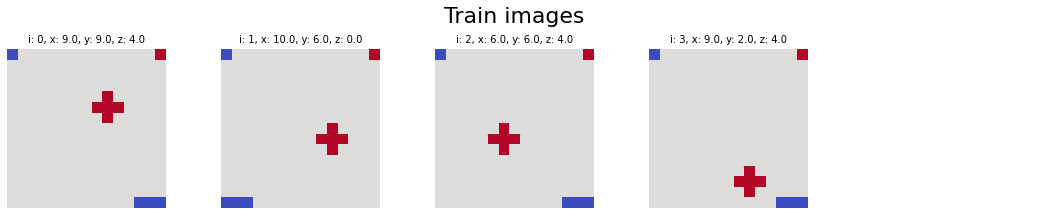

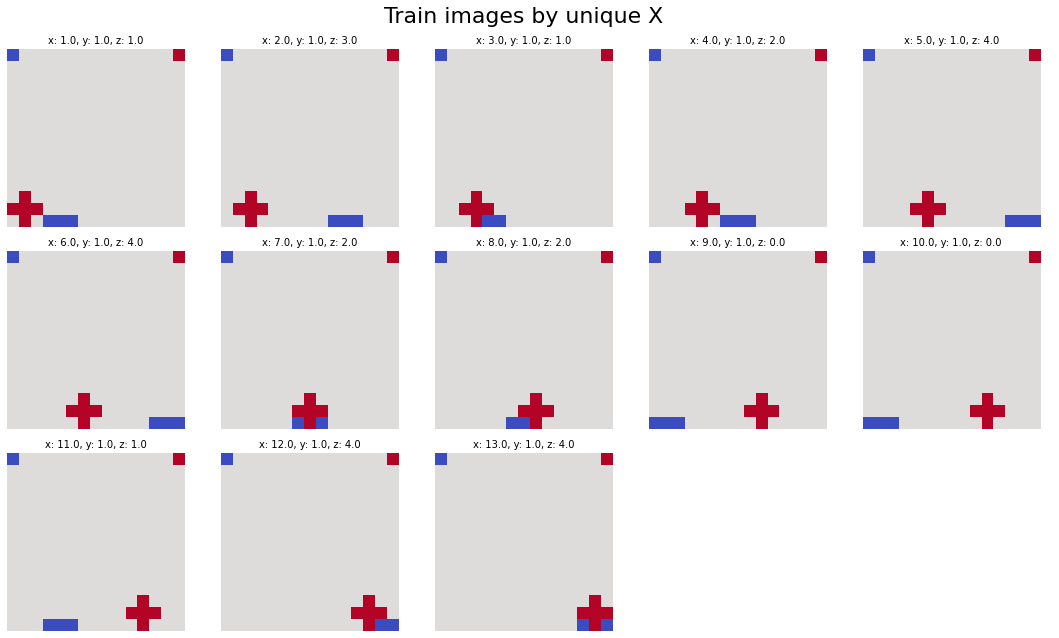

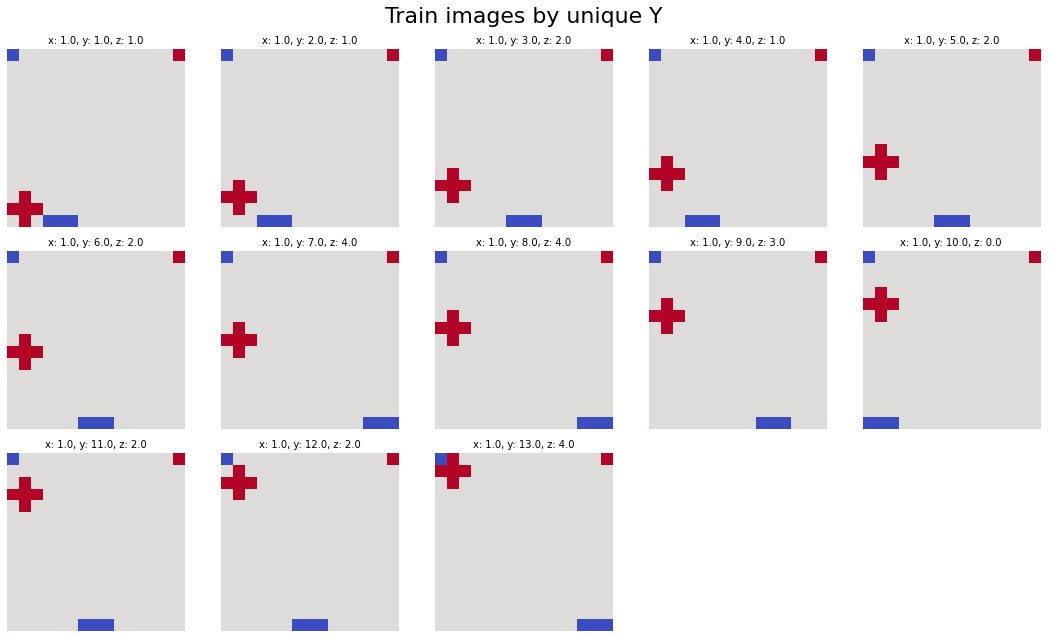

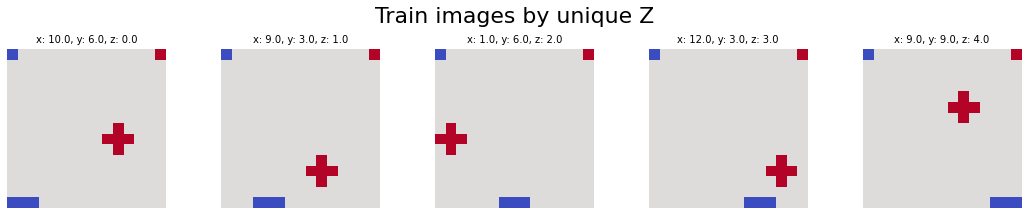

In [8]:
# Plotting Images
plotImg(trainPix, trainLabels, title="Train images")
plotImg(trainPix, trainLabels, filterAxis=0, constantAxis=1, constantValue=1, title="Train images by unique X")
plotImg(trainPix, trainLabels, filterAxis=1, constantAxis=0, constantValue=1, title="Train images by unique Y")
plotImg(trainPix, trainLabels, filterAxis=2, title="Train images by unique Z")

## CNN

#### Data preparation

In [9]:
# Encoder
encoder = OneHotEncoder(sparse=False) # the sparse argument is different for different versions of scikit-learn (sparse /sparse_output ) please adjust accordingly

# Prepare tensor labels using one-hot encoding
trainXLabels = torch.tensor(encoder.fit_transform(trainLabels[:, 0].reshape(-1, 1)), dtype=torch.float32)
trainYLabels = torch.tensor(encoder.fit_transform(trainLabels[:, 1].reshape(-1, 1)), dtype=torch.float32)
trainZLabels = torch.tensor(encoder.fit_transform(trainLabels[:, 2].reshape(-1, 1)), dtype=torch.float32)

testXLabels = torch.tensor(encoder.fit_transform(testLabels[:, 0].reshape(-1, 1)), dtype=torch.float32)
testYLabels = torch.tensor(encoder.fit_transform(testLabels[:, 1].reshape(-1, 1)), dtype=torch.float32)
testZLabels = torch.tensor(encoder.fit_transform(testLabels[:, 2].reshape(-1, 1)), dtype=torch.float32)

# Tensor objects
trainTensor = torch.tensor(trainPix.copy(), dtype=torch.float32)
testTensor = torch.tensor(testPix.copy(), dtype=torch.float32)

# Tensor datasets
XtrainDataset = TensorDataset(trainTensor, trainXLabels)
XtestDataset = TensorDataset(testTensor, testXLabels)

xyzTrainDataset = TensorDataset(trainTensor, trainXLabels, trainYLabels, trainZLabels)
xyzTestDataset = TensorDataset(testTensor, testXLabels,testYLabels,testZLabels)

# Train test loaders
XtrainLoader = DataLoader(XtrainDataset, batch_size=32, shuffle=True)
XtestLoader = DataLoader(XtestDataset, batch_size=32, shuffle=False)

xyzTrainLoader = DataLoader(xyzTrainDataset, batch_size=32, shuffle=True)
xyzTestLoader = DataLoader(xyzTestDataset, batch_size=32, shuffle=False)

### 2. Create a CNN that predicts the x-coordinate of the + marker. 


#### Network architecture

In [10]:
# Define a simple CNN class inheriting from nn.Module
class simpleCNN(nn.Module):
    def __init__(self, numClass):
        # Initialise the superclass nn.Module
        super(simpleCNN, self).__init__()
        # First convolutional layer with 1 input channel, 6 output channels, kernel size of 5, and padding of 2
        # This keeps the output size equal to the input size when the stride is 1
        self.conv1 = nn.Conv2d(1, 6, 5, padding=2)
        # Pooling layer to reduce spatial dimensions by half, using a 2x2 window and a stride of 2
        self.pool = nn.MaxPool2d(2, 2)
        # Second convolutional layer with 6 input channels, 16 output channels, kernel size of 5, and padding of 2
        # This layer also maintains the output spatial dimensions as the input dimensions with stride 1
        self.conv2 = nn.Conv2d(6, 16, 5, padding=2)
        # First fully connected layer, converting the 3x3x16 feature maps to 120 features
        # Calculation for input features: 16 channels * 3 width * 3 height = 144 features 
        self.fc1 = nn.Linear(16 * 3 * 3, 120)
        # Second fully connected layer, mapping 120 features to 84 features
        self.fc2 = nn.Linear(120, 84)
        # Third fully connected layer, outputting 13 class scores from 84 features
        self.fc3 = nn.Linear(84, numClass)

    def forward(self, x):
        # Apply first convolutional layer followed by ReLU activation and pooling
        x = self.pool(F.relu(self.conv1(x)))
        # Apply second convolutional layer followed by ReLU activation and pooling
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten the pooled feature maps into a single vector per image in the batch
        x = torch.flatten(x, 1)
        # Apply first fully connected layer with ReLU activation
        x = F.relu(self.fc1(x))
        # Apply second fully connected layer with ReLU activation
        x = F.relu(self.fc2(x))
        # Compute final output scores for each class using the third fully connected layer
        # No activation applied here, assuming it will be included in the loss function for multi-class classification using the cross entropy loss
        return self.fc3(x)


#### Initialise the model and train

In [11]:
# Instantiate the network and define the loss function and optimizer
net = simpleCNN(numClass = trainXLabels.shape[1])
net.train()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

Epoch 100: Average Loss: 2.553
Epoch 200: Average Loss: 0.042
Epoch 300: Average Loss: 0.004
Total Training Time: 11.55 seconds


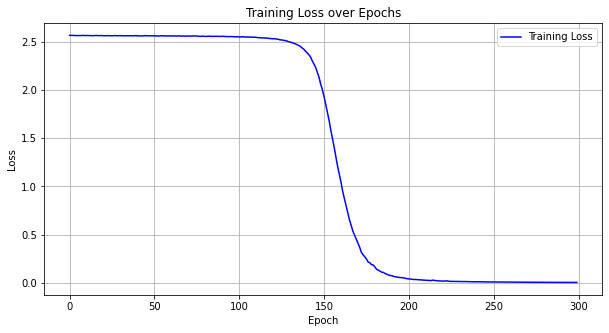

In [12]:
# Initialize variables to track loss
epoch_losses = []

# Start the timer
start_time = time.time()

# Training the network
for epoch in range(300):  # Set to 50 or 100 to get misclassifications to test whether the model is working
    running_loss = 0.0

    for i, data in enumerate(XtrainLoader, 0):
        inputs, labels = data

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = net(inputs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

    # Store average loss for this epoch
    average_loss = running_loss / len(XtrainLoader)
    epoch_losses.append(average_loss)

    # Print loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}: Average Loss: {average_loss:.3f}')

torch.save(net.state_dict(), f'xmodel_epoch_{epoch+1}.pth')

# Calculate total training time
total_time = time.time() - start_time
print(f'Total Training Time: {total_time:.2f} seconds')

# Plot the loss curve
plt.figure(figsize=(10, 5))
plt.plot(epoch_losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.savefig(f"{plt.gca().get_title()}.png")
plt.show()

#### Test the simple CNN network

Total test Time: 0.05 seconds
   xPredict
0        13
1         4
2         8
3         4
4        11
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        12
         2.0       1.00      1.00      1.00        15
         3.0       1.00      1.00      1.00         6
         4.0       1.00      1.00      1.00        13
         5.0       1.00      1.00      1.00         8
         6.0       1.00      1.00      1.00        19
         7.0       1.00      1.00      1.00        14
         8.0       1.00      1.00      1.00        14
         9.0       1.00      1.00      1.00        14
        10.0       1.00      1.00      1.00        12
        11.0       1.00      1.00      1.00        16
        12.0       1.00      1.00      1.00        11
        13.0       1.00      1.00      1.00        15

    accuracy                           1.00       169
   macro avg       1.00      1.00      1.00       169
weighted avg       1.00      1.0

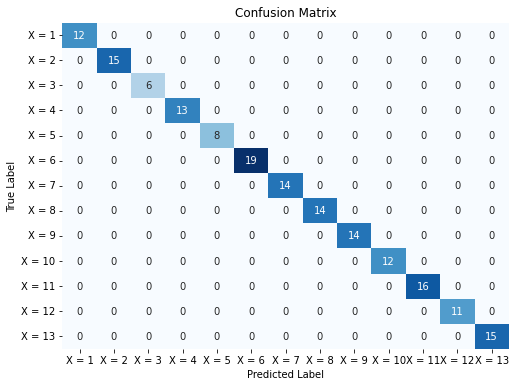

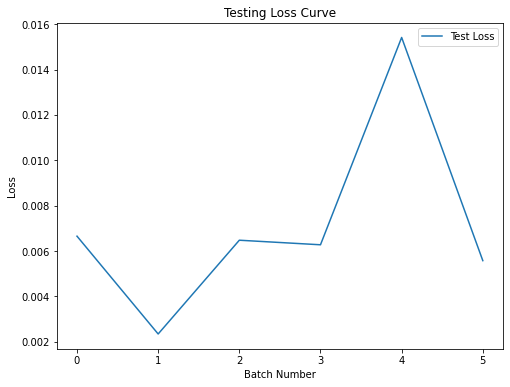

In [13]:
# Set the network to evaluation mode
net.eval()

# Start the timer
start_time = time.time()

# Lists to store predicted labels 
predictedLabels = []
losses = []

# Criterion for loss computation
criterion = torch.nn.CrossEntropyLoss()

# Generate predictions for the test set and compute loss
with torch.no_grad():
    for images, labels in XtestLoader:
        outputs = net(images)
        loss = criterion(outputs, labels)
        losses.append(loss.item())
        _, predicted = torch.max(outputs, 1)
        # Store predicted labels, adjusting class index by 1
        predictedLabels.extend(predicted.numpy() + 1)

# Calculate total test time
total_time = time.time() - start_time
print(f'Total test Time: {total_time:.2f} seconds')

# Create a DataFrame for storing the results
testPredLabels = pd.DataFrame({
    'xPredict': predictedLabels
})

# Print the predicted labels for verification
print(testPredLabels.head())  # Print first few rows for sanity check

# Save the results to a CSV file
testPredLabels.to_csv('xPredict.csv', index=False)

# Compare predictions with true labels
testXLabels = testLabels[:,0]
confMat = confusion_matrix(y_true=testXLabels, y_pred=predictedLabels)
classReport = classification_report(y_true=testXLabels, y_pred=predictedLabels)
print(classReport)

# Plotting the confusion matrix
xCoord = [f'X = {i}' for i in range(1, 14)]
plt.figure(figsize=(8, 6))
sns.heatmap(confMat, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=xCoord, yticklabels=xCoord)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.savefig(f"{plt.gca().get_title()}.png", bbox_inches='tight')
plt.show()

# Plotting the testing loss curve
plt.figure(figsize=(8, 6))
plt.plot(losses, label='Test Loss')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.title('Testing Loss Curve')
plt.legend()
plt.savefig('Testing Loss Curve.png')
plt.show()

#### Weights of the convolutional layers

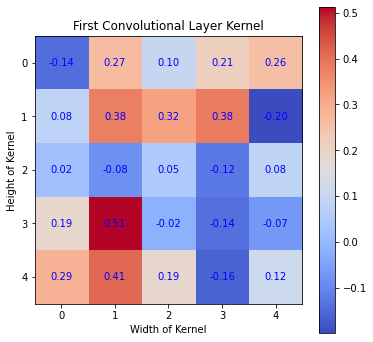

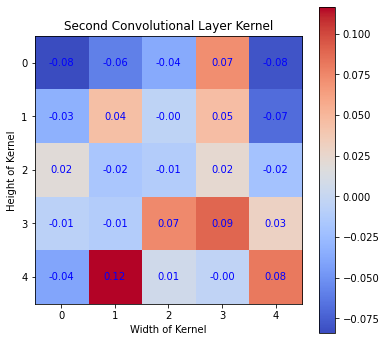

In [14]:
# Retrieve and plot the weights of the first convolutional layer
weights1 = net.conv1.weight.data.numpy()
plt.figure(figsize=(6, 6))  # Set a larger figure size for better visibility
plt.imshow(weights1[0, 0, :, :], cmap='coolwarm', interpolation='nearest')  # 'nearest' interpolation shows the pixels as square blocks
plt.colorbar()  # Add a colorbar to show the color scale
plt.title("First Convolutional Layer Kernel")
plt.xlabel('Width of Kernel')
plt.ylabel('Height of Kernel')
# Optionally, add weight annotations within the plot
for i in range(weights1.shape[2]):
    for j in range(weights1.shape[3]):
        plt.text(j, i, f'{weights1[0, 0, i, j]:.2f}', ha='center', va='center', color='blue')
plt.savefig(f"{plt.gca().get_title()}.png")
plt.show()

# Retrieve and plot the weights of the second convolutional layer
weights2 = net.conv2.weight.data.numpy()
plt.figure(figsize=(6, 6))  # Same enhancements as above
plt.imshow(weights2[0, 0, :, :], cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.title("Second Convolutional Layer Kernel")
plt.xlabel('Width of Kernel')
plt.ylabel('Height of Kernel')
# Optionally, add weight annotations within the plot
for i in range(weights2.shape[2]):
    for j in range(weights2.shape[3]):
        plt.text(j, i, f'{weights2[0, 0, i, j]:.2f}', ha='center', va='center', color='blue')
plt.savefig(f"{plt.gca().get_title()}.png")
plt.show()

### 3. Create a CNN that predicts all three outputs (x, y, z) from each input.2

In [15]:
# Multi-Task Learning CNN
class multiCNN(nn.Module):
    def __init__(self, numClassX, numClassY, numClassZ):
        super(multiCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5, padding=2)
        self.conv3 = nn.Conv2d(16, 8, 3)
        self.dropout = nn.Dropout(p=0.1)
        self.fc1 = nn.Linear(8 * 1 * 1, 120) 
        self.fc2 = nn.Linear(120, 84)
        self.outX = nn.Linear(84, numClassX)
        self.outY = nn.Linear(84, numClassY)
        self.outZ = nn.Linear(84, numClassZ)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.outX(x), self.outY(x), self.outZ(x)

#### Initialise and train

In [16]:
multinet = multiCNN(13, 13, 5)
multinet.train()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(multinet.parameters(), lr=5e-3)

Epoch 1, Loss: 2.2474796013398604
Epoch 100, Loss: 0.7703920006752014
Epoch 200, Loss: 0.6844550154425881
Epoch 300, Loss: 0.654818058013916
Epoch 400, Loss: 0.6337910917672244
Epoch 500, Loss: 0.6092952002178539
Finished Training in 37.19 seconds


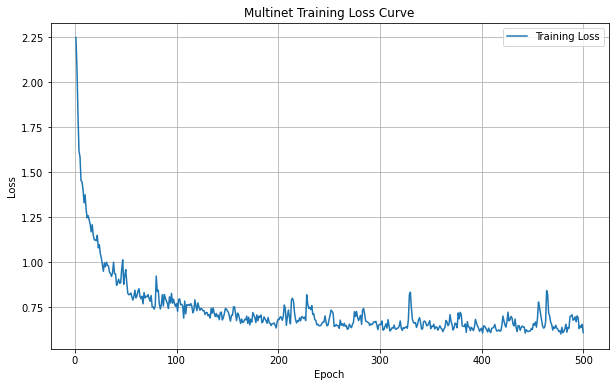

In [17]:
# Initialize variables to store training loss and start time
losses = []
start_time = time.time()

# Training loop
num_epochs = 500  

for epoch in range(num_epochs):
    running_loss = 0.0
    for inputs, labelsX, labelsY, labelsZ in xyzTrainLoader:
        optimizer.zero_grad()

        # Forward pass
        outputsX, outputsY, outputsZ = multinet(inputs)

        # Compute loss for each task
        lossX = criterion(outputsX, labelsX)
        lossY = criterion(outputsY, labelsY)
        lossZ = criterion(outputsZ, labelsZ)

        # Combine losses
        loss = (lossX + lossY + lossZ)/3

        # Backward and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss for the epoch
    avg_loss = running_loss / len(xyzTrainLoader)
    losses.append(avg_loss)

    # Print the loss every 100 epochs
    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss}")

torch.save(multinet.state_dict(), f'multinet_epoch_{epoch+1}.pth')

# Calculate total training time
end_time = time.time()
training_time = end_time - start_time
print(f'Finished Training in {training_time:.2f} seconds')

# Plot training loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Multinet Training Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig("Multinet Training Loss Curve")
plt.show()

Total test Time: 0.01 seconds
Classification Report for Task X:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        19
           6       1.00      1.00      1.00        14
           7       1.00      1.00      1.00        14
           8       1.00      0.79      0.88        14
           9       0.80      1.00      0.89        12
          10       1.00      0.94      0.97        16
          11       0.92      1.00      0.96        11
          12       1.00      1.00      1.00        15

    accuracy                           0.98       169
   macro avg       0.98      0.98      0.98       169
weighted avg       0.98      0.98      0.98       169

Confusion Mat

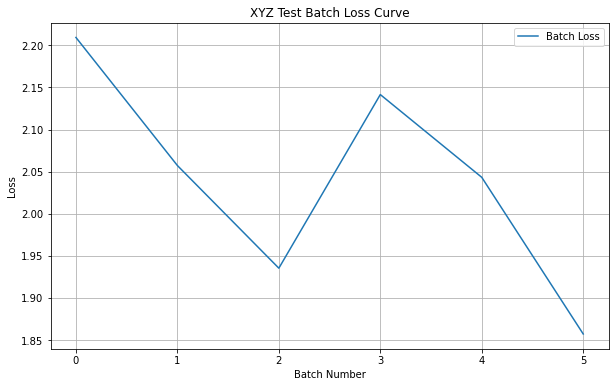

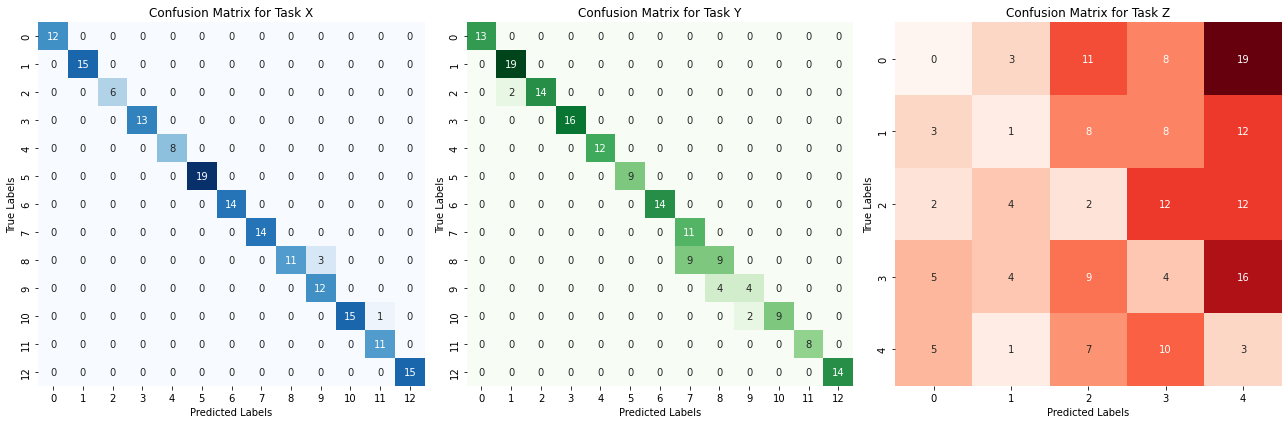

In [18]:
# checkpoint = torch.load('multinet_epoch_2000.pth')

# Load the weights into the multinet model
# multinet.load_state_dict(checkpoint)

# After loading the weights, you typically set the model to evaluation mode if you're testing
multinet.eval()

# Assuming testLabels is structured as Numpy array or similar
labelsX = testLabels[:, 0]
labelsY = testLabels[:, 1]
labelsZ = testLabels[:, 2]

# Set the network to evaluation mode
multinet.eval()

# Start the timer
startTime = time.time()

# Lists to store labels and predictions for each task
trueLabelsX, predictedLabelsX = [], []
trueLabelsY, predictedLabelsY = [], []
trueLabelsZ, predictedLabelsZ = [], []

# Loss storage for each batch
batchLosses = []

# Enumerate over the test loader and use index to access labels
for i, (inputs, labelsX, labelsY, labelsZ) in enumerate(xyzTestLoader):
    # Convert labels to tensors; assume they are one-hot encoded and need conversion to class indices
    currentLabelsX = torch.argmax(labelsX, dim=1)
    currentLabelsY = torch.argmax(labelsY, dim=1)
    currentLabelsZ = torch.argmax(labelsZ, dim=1)

    # Forward pass
    outputsX, outputsY, outputsZ = multinet(inputs)

    # Compute loss for each task
    lossX = criterion(outputsX, currentLabelsX)
    lossY = criterion(outputsY, currentLabelsY)
    lossZ = criterion(outputsZ, currentLabelsZ)
    totalLoss = lossX + lossY + lossZ

    # Append batch loss to the list
    batchLosses.append(totalLoss.item())

    # Store true and predicted labels for later evaluation
    _, predsX = torch.max(outputsX, 1)
    _, predsY = torch.max(outputsY, 1)
    _, predsZ = torch.max(outputsZ, 1)

    trueLabelsX.extend(currentLabelsX.tolist())
    predictedLabelsX.extend(predsX.tolist())
    trueLabelsY.extend(currentLabelsY.tolist())
    predictedLabelsY.extend(predsY.tolist())
    trueLabelsZ.extend(currentLabelsZ.tolist())
    predictedLabelsZ.extend(predsZ.tolist())

# Calculate total test time
totalTime = time.time() - startTime
print(f'Total test Time: {totalTime:.2f} seconds')

# Confusion matrix and classification reports for each task
confMatX = confusion_matrix(trueLabelsX, predictedLabelsX)
reportX = classification_report(trueLabelsX, predictedLabelsX)
print("Classification Report for Task X:\n\n", reportX)
print("Confusion Matrix for Task X:\n", confMatX)

confMatY = confusion_matrix(trueLabelsY, predictedLabelsY)
reportY = classification_report(trueLabelsY, predictedLabelsY)
print("Classification Report for Task Y:\n\n", reportY)
print("Confusion Matrix for Task Y:\n", confMatY)

confMatZ = confusion_matrix(trueLabelsZ, predictedLabelsZ)
reportZ = classification_report(trueLabelsZ, predictedLabelsZ)
print("Classification Report for Task Z:\n\n", reportZ)
print("Confusion Matrix for Task Z:\n", confMatZ)

# Plot the batch loss curve
plt.figure(figsize=(10, 6))
plt.plot(batchLosses, label='Batch Loss')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.title('XYZ Test Batch Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig('XYZ Test Batch Loss Curve')
plt.show()

# Create a figure for plotting
plt.figure(figsize=(18, 6))

# Plot for Task X
plt.subplot(1, 3, 1)
sns.heatmap(confMatX, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Task X')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Plot for Task Y
plt.subplot(1, 3, 2)
sns.heatmap(confMatY, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix for Task Y')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Plot for Task Z
plt.subplot(1, 3, 3)
sns.heatmap(confMatZ, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Confusion Matrix for Task Z')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.tight_layout()
plt.savefig(f'XYZ classification matrices')
plt.show()

#### The above classification model using cross-entropy loss is not optimal. Increasing the number of epochs did not yield better results. A more effective approach for multi-class classification of the x, y, and z coordinates is to use regression. Each class can be converted into a numerical interval, and the predicted regression value is then rounded to the nearest class, with x.5 serving as the threshold.

## Task 2: Train a convolutional autoencoder 

Instead of predicting positions, create a convolutional autoencoder that compresses the MiniPong
screenshots to a small number of bytes (the encoder), and then transforms them back to the
original form (in the decoder part).
Steps
1. Create and train an (undercomplete) convolutional autoencoder using the training dataset
from the first task.
2. It is up to you to choose the architecture of the network and the size of the representation
h= f(x). The goal is to learn a representation that is smaller than the original image while
still leading to recognisable reconstructions.
3. For the encoder, you may use the same architecture as in the first task, but you cannot use
the labels for training. Alternatively, you may choose a completely diﬀerent architecture.
4. (No programming): In theory, what is the absolute minimal size of the hidden layer
representation that allows perfect reconstruction of the original image?
What to submit for task 2: the Python code for your solution and a description of it.
- In your report, provide a brief description of your steps to create the models and your
observations. Describe what you did (e.g., what loss function you used, the size of the
encoded image in your architecture, and the number of training steps).
- Include screenshots of 1-2 output images next to the original inputs (e.g., select one good
and one bad example).

### 1. Create and train an (undercomplete) convolutional autoencoder using the training dataset from the first task.

In [19]:
class MiniPongAutoencoder(nn.Module):
    def __init__(self):
        super(MiniPongAutoencoder, self).__init__()
        # Encoder
        # Conv2d with kernel_size=3, stride=2, padding=1
        # Input: (batch_size, 1, 15, 15)
        # Output: (batch_size, 16, 8, 8) -> (W-F+2P)/S + 1 = (15-3+2*1)/2 + 1 = 8
        self.conv1 = nn.Conv2d(1, 16, 3, stride=2, padding=1)
        
        # MaxPool2d with kernel_size=2, stride=2, padding=0
        # Input: (batch_size, 16, 8, 8)
        # Output: (batch_size, 16, 4, 4) -> 8/2 = 4
        self.pool1 = nn.MaxPool2d(2, stride=2)
        
        # Conv2d with kernel_size=3, stride=1, padding=1
        # Input: (batch_size, 16, 4, 4)
        # Output: (batch_size, 8, 4, 4) -> (4-3+2*1)/1 + 1 = 4
        self.conv2 = nn.Conv2d(16, 8, 3, stride=1, padding=1)
        
        # Decoder
        # ConvTranspose2d with kernel_size=3, stride=2, padding=1, output_padding=1
        # Input: (batch_size, 8, 4, 4)
        # Output: (batch_size, 16, 8, 8) -> (4-1)*2 - 2*1 + 3 + 1 = 8
        self.iconv1 = nn.ConvTranspose2d(8, 16, 3, stride=2, padding=1, output_padding=1)
        
        # ConvTranspose2d with kernel_size=3, stride=2, padding=1, output_padding=0
        # Input: (batch_size, 16, 8, 8)
        # Output: (batch_size, 1, 15, 15) -> (8-1)*2 - 2*1 + 3 + 0 = 15
        self.iconv2 = nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=0)
    
    def encoder(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        return x

    def decoder(self, x):
        x = F.relu(self.iconv1(x))
        x = torch.tanh(self.iconv2(x))
        return x

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

### 2. It is up to you to choose the architecture of the network and the size of the representation h= f(x). The goal is to learn a representation that is smaller than the original image while still leading to recognisable reconstructions.

**Input dimension = 15x15 = 225**

**Latent Dimension [h = f(x)] = 128**


### 3. For the encoder, you may use the same architecture as in the first task, but you cannot use the labels for training. Alternatively, you may choose a completely diﬀerent architecture.

In [20]:
trainAutoLoader = DataLoader(TensorDataset(trainTensor), batch_size=32, shuffle=True)
testAutoLoader = DataLoader(TensorDataset(testTensor), batch_size=32, shuffle=False)

In [21]:
# Training setup
model = MiniPongAutoencoder()
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)
num_epochs = 501

Epoch 1, Average Loss: 0.1078


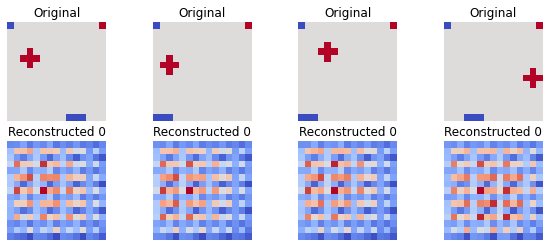

Epoch 51, Average Loss: 0.0083


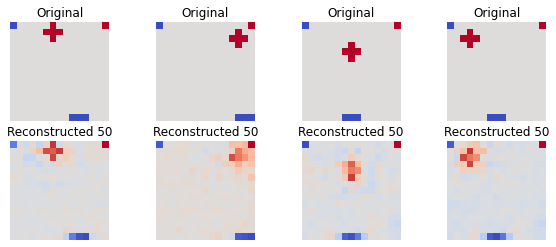

Epoch 101, Average Loss: 0.0040


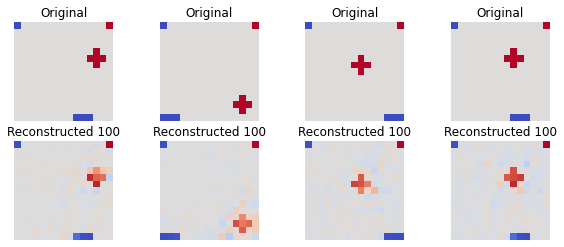

Epoch 151, Average Loss: 0.0020


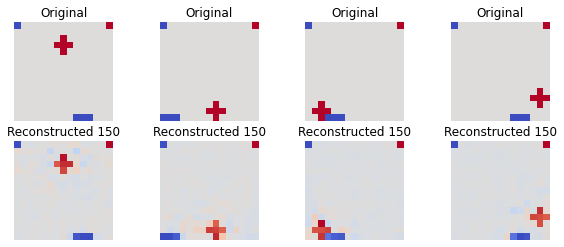

Epoch 201, Average Loss: 0.0012


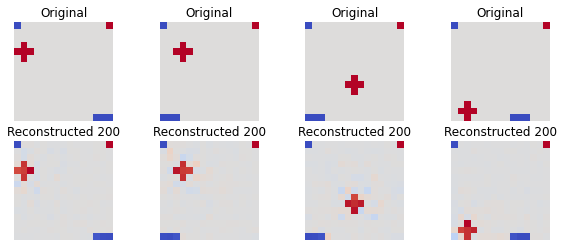

Epoch 251, Average Loss: 0.0008


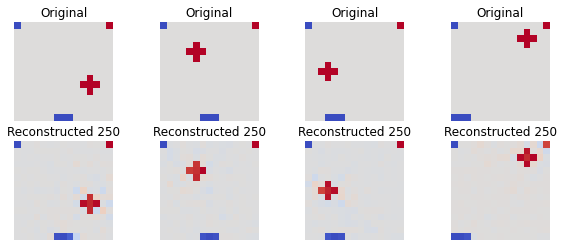

Epoch 301, Average Loss: 0.0006


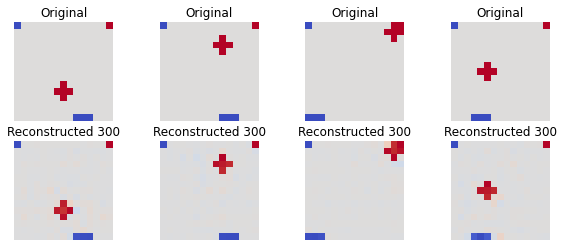

Epoch 351, Average Loss: 0.0004


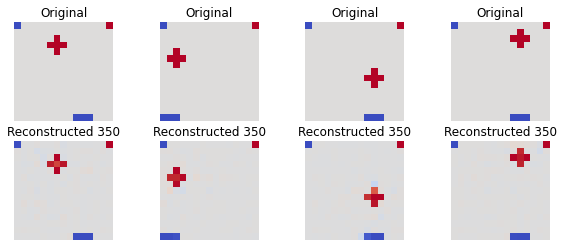

Epoch 401, Average Loss: 0.0003


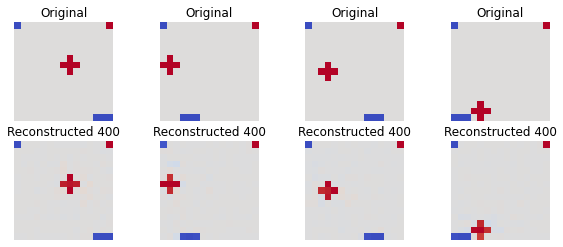

Epoch 451, Average Loss: 0.0002


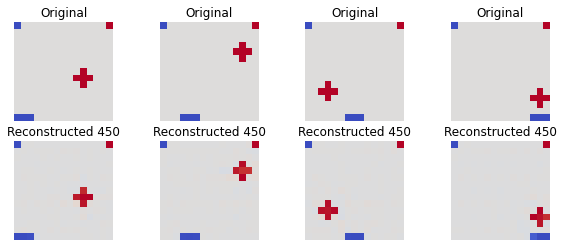

Epoch 501, Average Loss: 0.0002


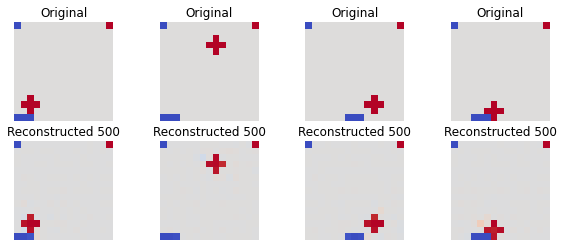

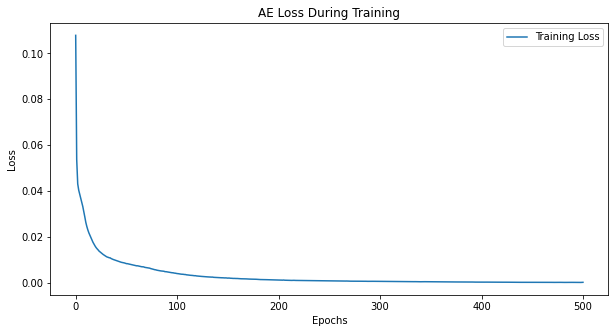

Total training time (Epoch = 500): 31.50 seconds


In [22]:
losses = []
start_time = time.time()
model.train()

# Training loop
for epoch in range(num_epochs):
    epoch_loss = 0
    for data in trainAutoLoader:
        img = data[0]
        optimizer.zero_grad()
        output = model(img)
        
        loss = criterion(output, img)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Average loss for the epoch
    epoch_loss /= len(trainAutoLoader)
    losses.append(epoch_loss)
    
    if epoch % 50 == 0:
    # Output every epoch to monitor progress
        print(f'Epoch {epoch+1}, Average Loss: {epoch_loss:.4f}')

    # Plot and save images every 10 epochs
    if epoch % 50 == 0:
        with torch.no_grad():
            # Get a batch of images and their reconstructions
            sample_images = img[:4]
            reconstructed_images = model(sample_images).cpu().numpy()
            plotAE(sample_images.cpu().numpy(), reconstructed_images, epoch, n=4)

# Loss plot
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss')
plt.title('AE Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig("'AE Loss During Training'")
plt.show()

# Training time
training_time = time.time() - start_time
print(f'Total training time (Epoch = {epoch}): {training_time:.2f} seconds')

# Save the model
torch.save(model.state_dict(), './miniPong_autoencoder.pth')

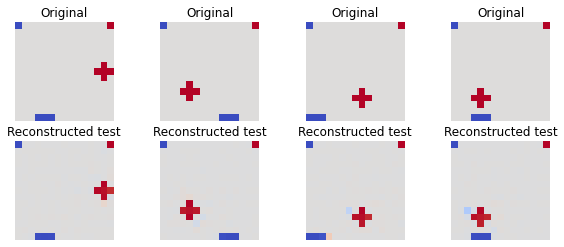

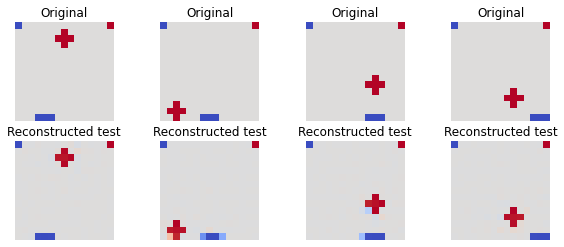

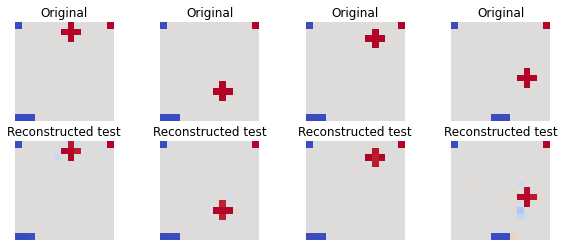

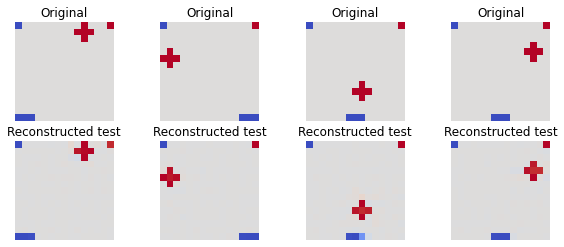

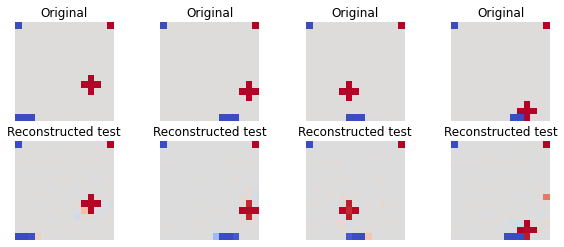

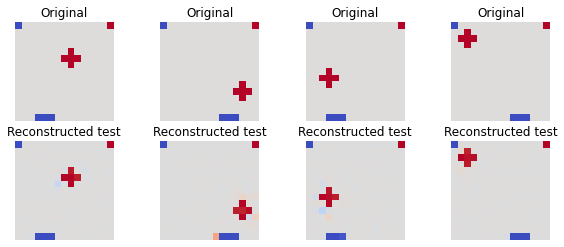

Average Test Loss: 0.0004


In [23]:
model.load_state_dict(torch.load('./miniPong_autoencoder.pth'))

# Switch to evaluation mode
model.eval()

test_losses = []
with torch.no_grad():
    # Testing loop
    for data in testAutoLoader:
        img = data[0]
        output = model(img)

        # Calculate loss
        test_loss = criterion(output, img)
        test_losses.append(test_loss.item())

        # Plotting and saving reconstructed images
        original_images = img.cpu().numpy()
        reconstructed_images = output.cpu().numpy()
        
        # Choose only a few images to plot to avoid clutter
        plotAE(original_images, reconstructed_images, 'test')

# Average test loss
average_test_loss = sum(test_losses) / len(test_losses)
print(f'Average Test Loss: {average_test_loss:.4f}')

In [24]:
# Create the function to add Gaussian noise to the batch of images
def add_noise(img):
    noise = torch.randn(img.size()) * 0.2  # Ensure to use 'torch.randn' for Gaussian noise
    noisy_img = img + noise
    return noisy_img

# Function to prepare the image grid for saving
def to_img(x):
    x = 0.5 * (x + 1)  # Normalize the images to [0, 1]
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 1, 15, 15)  # Adjust the shape to [batch_size, channels, height, width]
    return x

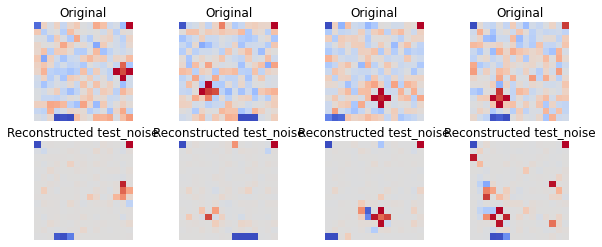

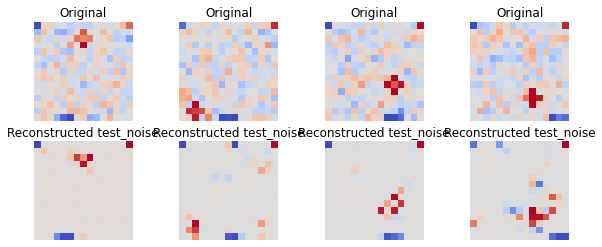

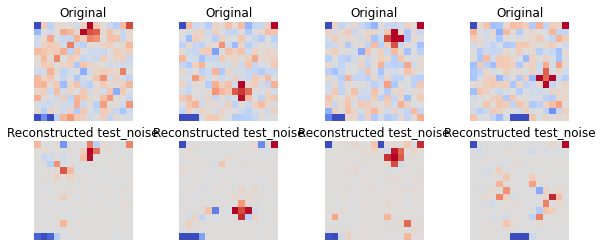

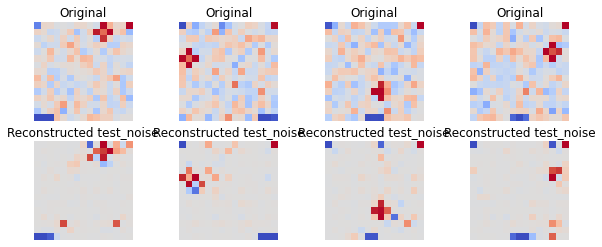

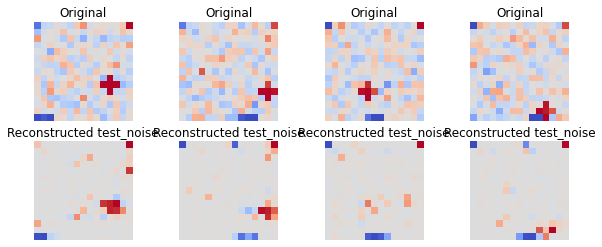

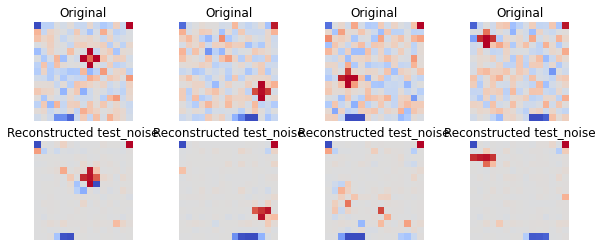

Average Test Loss: 0.0183


In [25]:
# Switch to evaluation mode
model.eval()

test_losses = []
with torch.no_grad():
    # Testing loop with noise addition
    for data in testAutoLoader:
        img = data[0]
        noisy_img = add_noise(img)  # Add noise to the images
        output = model(noisy_img)   # Reconstruct the noisy images

        # Calculate loss on the noisy images vs original clean images
        test_loss = criterion(output, img)
        test_losses.append(test_loss.item())

        # Preparing images for saving
        original_images = to_img(img).cpu().numpy()
        noisy_images = to_img(noisy_img).cpu().numpy()
        reconstructed_images = to_img(output).cpu().numpy()

        # Plot and save original, noisy, and reconstructed images
        plotAE(noisy_images, reconstructed_images, 'test_noise')

# Average test loss
average_test_loss = sum(test_losses) / len(test_losses)
print(f'Average Test Loss: {average_test_loss:.4f}')

### 4. (No programming): In theory, what is the absolute minimal size of the hidden layer representation that allows perfect reconstruction of the original image? What to submit for task 2: the Python code for your solution and a description of it.

## Task 3: Create an RL agent for MiniPong 

The code in mini pong.py provides an environment similar in style to other gymnasium environments, with diﬀerent levels and sizes. Below is a description of the environment dynamics:

• The ball+ marker moves diagonally at each step. When it hits the paddle or a wall (top,
left, or right), it reflects.

• The agent controls the paddle−, moving it one 3-pixel slot per step. The agent has three
actions available: do nothing, move left, or move right. The paddle cannot move outside
the boundaries.

• The agent receives a positive reward when the + marker reflects oﬀ the paddle. In this
case, the + may also move randomly by 1 or 2 pixels left or right.

• An episode ends when the + reaches the bottom row without reflecting oﬀ the paddle.
In the level 1 version of the environment, the observed state (the information available to the
agent after each step) consists of a single value, dz: the relative position of the + marker to the
centre of the paddle−. This value is negative if the + marker is on one side, and positive if on
the other.

For this task, you should use level=1 and size=5. You can choose to normalise the state
information to values between -1 and 1 by setting normalise=True, or use the original (integer)
values in the range−13...13 by setting normalise=False.

env = M i n i P o n g E n v ( level =1 , size =5 , normalise = True )

**Steps**
1. First, create a simple Python program (without RL) that plays MiniPong. The program
should select an action based on the value of dz. You may use and modify the code at the
end of mini pong.py to complete this task.
2. Create an RL agent (tabular or deep) that learns to play MiniPong. If you use a TD-learning
approach with ϵ-greedy action selection, set ϵ = 1 initially, and slowly reduce it during
training to a minimum of 0.1.
3. Run your training, resetting the environment after each episode. Store the sum of rewards
for each episode. After or during training, plot the total sum of rewards per episode. This
plot — the Training Reward plot — indicates the extent to which your agent is improving
its cumulative reward. It is your decision when to stop training. It is not required to submit
a perfectly performing agent, but show how it learns.
4. After deciding the training is complete, run 50 test episodes using your trained policy
with ϵ= 0.0 for all 50 episodes. Reset the environment at the beginning of each episode.
Calculate the average of the sum of rewards per episode (call this the Test-Average) and the
standard deviation (the Test-Standard-Deviation). These values indicate how your trained
agent performs.
5. (No programming required) Describe: In level 2 of MiniPong, the observed state would
consist of 2 values instead of 1: it now contains the ball’s y-coordinate as well as the relative
position dz (that we also get in level 1). Would this additional information help or hinder
learning?

**What to submit:**
- Submit the Python code for your solutions (both the manual strategy and the RL agent).
- In your report, describe your solution, mention the Test-Average and Test-Standard-
Deviation, and include the Training Reward plot described above. Indicate how many
episodes you ran before stopping training and how long the process took.
- Include your response to the question about the level 2 version of the environment.

In [26]:
from mini_pong import MiniPongEnv
env = MiniPongEnv(level = 1, size =5, normalise = True)

### 1. First, create a simple Python program (without RL) that plays MiniPong. The program should select an action based on the value of dz. You may use and modify the code at the end of mini pong.py to complete this task.

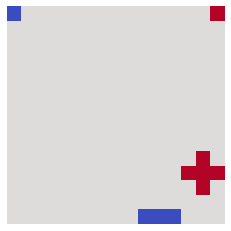

State: [0.23076923], Reward: 0.0, Done: False


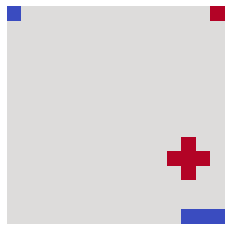

State: [-0.07692308], Reward: 0.0, Done: False


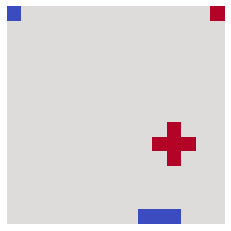

State: [0.07692308], Reward: 0.0, Done: False


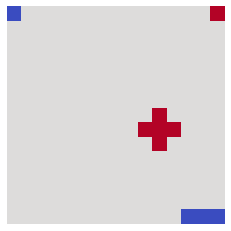

State: [-0.23076923], Reward: 0.0, Done: False


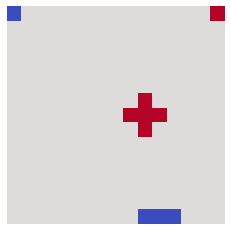

State: [-0.07692308], Reward: 0.0, Done: False


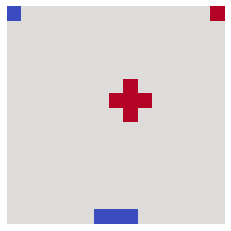

State: [0.07692308], Reward: 0.0, Done: False


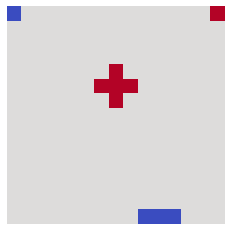

State: [-0.23076923], Reward: 0.0, Done: False


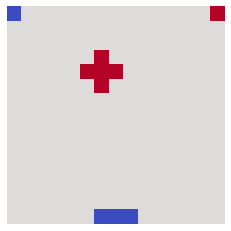

State: [-0.07692308], Reward: 0.0, Done: False


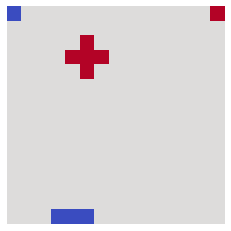

State: [0.07692308], Reward: 0.0, Done: False


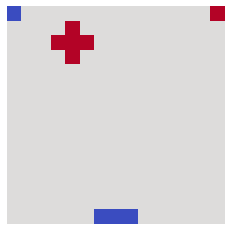

State: [-0.23076923], Reward: 0.0, Done: False


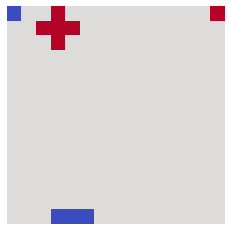

State: [-0.07692308], Reward: 0.0, Done: False


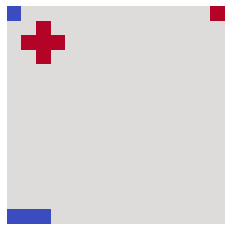

State: [0.07692308], Reward: 0.0, Done: False


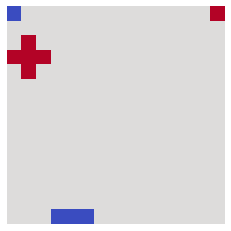

State: [-0.23076923], Reward: 0.0, Done: False


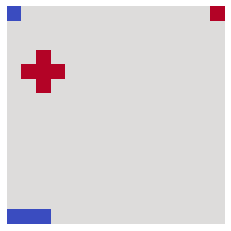

State: [0.07692308], Reward: 0.0, Done: False


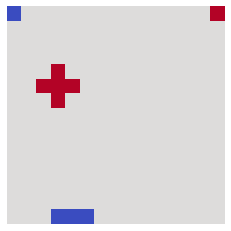

State: [-0.07692308], Reward: 0.0, Done: False


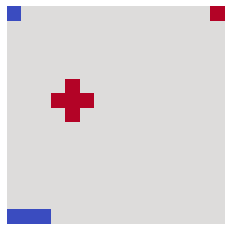

State: [0.23076923], Reward: 0.0, Done: False


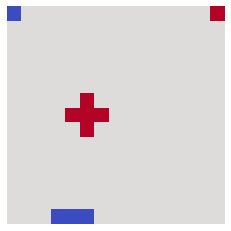

State: [0.07692308], Reward: 0.0, Done: False


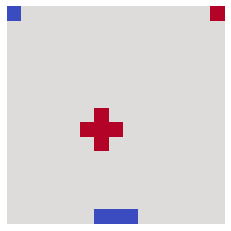

State: [-0.07692308], Reward: 0.0, Done: False


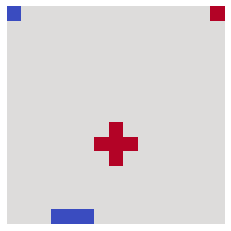

State: [0.23076923], Reward: 0.0, Done: False


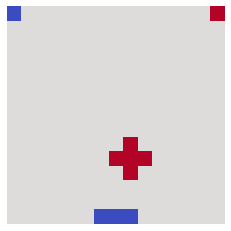

State: [0.07692308], Reward: 0.0, Done: False


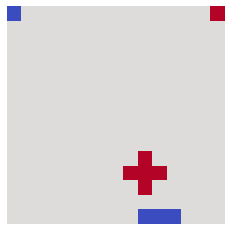

State: [-0.07692308], Reward: 0.0, Done: False


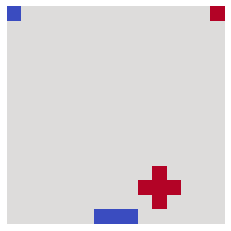

State: [0.23076923], Reward: 0.0, Done: False


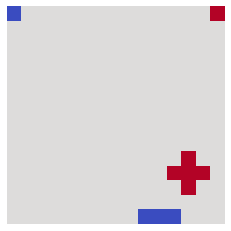

State: [0.15384615], Reward: 0.0, Done: False


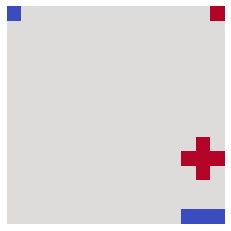

State: [0.], Reward: 0.0, Done: False


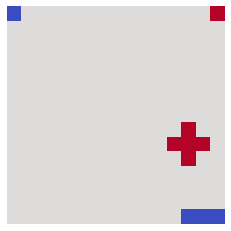

State: [-0.07692308], Reward: 0.0, Done: False


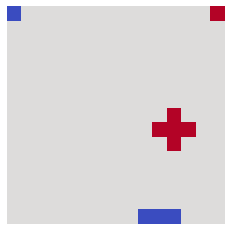

State: [0.07692308], Reward: 0.0, Done: False


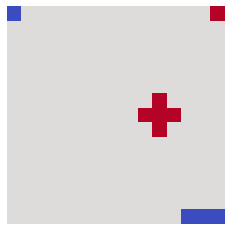

State: [-0.23076923], Reward: 0.0, Done: False


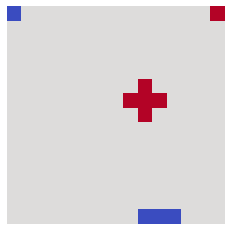

State: [-0.07692308], Reward: 0.0, Done: False


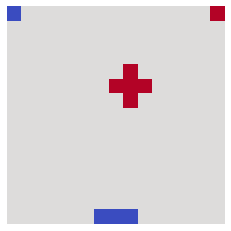

State: [0.07692308], Reward: 0.0, Done: False


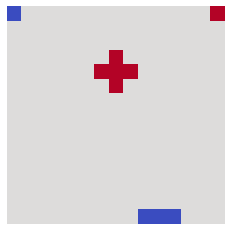

State: [-0.23076923], Reward: 0.0, Done: False


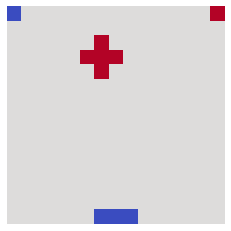

State: [-0.07692308], Reward: 0.0, Done: False


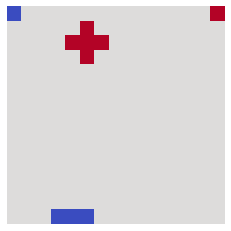

State: [0.07692308], Reward: 0.0, Done: False


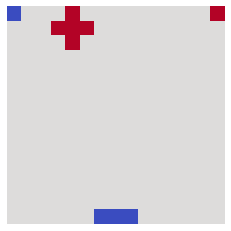

State: [-0.23076923], Reward: 0.0, Done: False


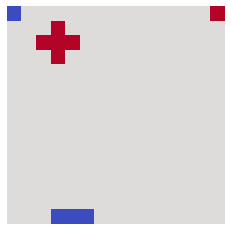

State: [-0.07692308], Reward: 0.0, Done: False


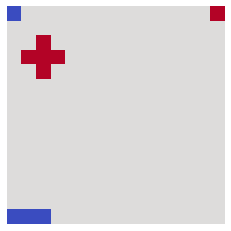

State: [0.07692308], Reward: 0.0, Done: False


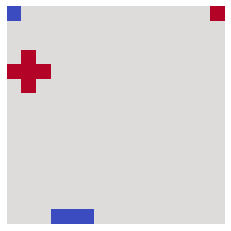

State: [-0.23076923], Reward: 0.0, Done: False


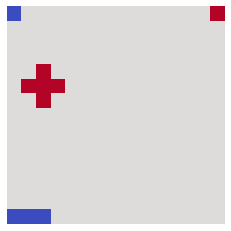

State: [0.07692308], Reward: 0.0, Done: False


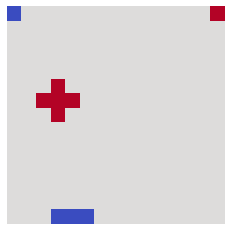

State: [-0.07692308], Reward: 0.0, Done: False


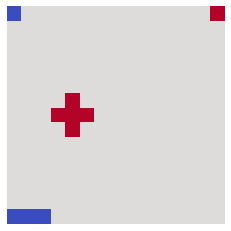

State: [0.23076923], Reward: 0.0, Done: False


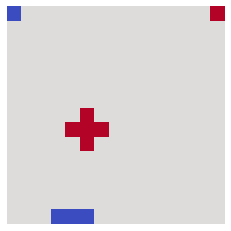

State: [0.07692308], Reward: 0.0, Done: False


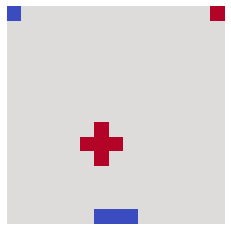

State: [-0.07692308], Reward: 0.0, Done: False


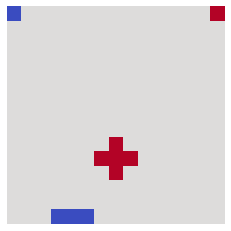

State: [0.23076923], Reward: 0.0, Done: False


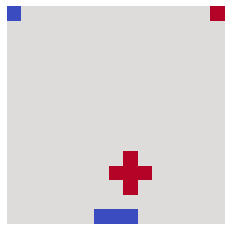

State: [0.07692308], Reward: 0.0, Done: False


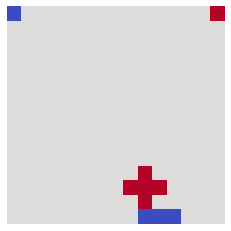

State: [-0.07692308], Reward: 13, Done: False


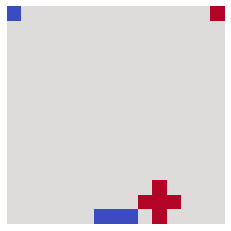

State: [0.23076923], Reward: 0.0, Done: True


In [27]:
if __name__ == "__main__":
    env = MiniPongEnv(level=1, size=5, normalise=True) # Set normalise=True To verify the states ( -13 to 13 including 0)
    state = env.reset()
    done = False

    while not done:
        # Extract dz from the state
        dz = state[0]  # State is a single value representing dz
        
        # Decide action based on the value of dz
        if dz < 0:
            action = 1  # Move paddle left
        elif dz > 0:
            action = 2  # Move paddle right
        else:
            action = 0  # No movement
        
        # Execute the chosen action
        state, reward, done, _ = env.step(action)
        env.render()
        print(f"State: {state}, Reward: {reward}, Done: {done}")


### 3. Create an RL agent (tabular or deep) that learns to play MiniPong. If you use a TD-learning approach with ϵ-greedy action selection, set ϵ = 1 initially, and slowly reduce it during training to a minimum of 0.1.

### A. SARSA (Tabular on-policy method)

In [28]:
num_states = 27 #(-13 to 13 including 0)

# Now, `env` is wrapped and you can use it as usual

def choose(q, state, epsilon):
    """
    epsilon-greedy action selection.
    """
    if random.random() <= epsilon:
        action = random.randint(0, len(q[state])-1)
    else:
        action = np.argmax(q[state])
    return action


def encode_state(dz, num_states):
    """
    Encode the continuous dz value to a discrete state.
    Scale and clip dz to ensure it maps into the range [0, num_states-1].
    """
    scaled_dz = int((dz + 1) * (num_states - 1) / 2)
    return np.clip(scaled_dz, 0, num_states - 1)


def sarsa(env, alpha, epsilon, gamma, num_episodes=500, num_states=27, num_actions=3):
    q = np.zeros((num_states, num_actions))  # Initialize Q-table
    rewards = []  # List to store rewards for plotting
    

    start = time.time()
    for episode in range(num_episodes):
        total_reward = 0
        state = env.reset()
        dz = state[0]
        current_state = encode_state(dz, num_states)
        action = choose(q, current_state, epsilon)

        done = False
        while not done:
            # env.render()
            next_state, reward, done, _ = env.step(action)
            next_dz = next_state[0]
            next_state_encoded = encode_state(next_dz, num_states)
            next_action = choose(q, next_state_encoded, epsilon)

            q[current_state, action] += alpha * (reward + gamma * q[next_state_encoded, next_action] - q[current_state, action])

            current_state = next_state_encoded
            action = next_action
            total_reward += reward
        # env.render()
        epsilon = max(0.1, epsilon * 0.99)  # Exponentially decay epsilon
        rewards.append(total_reward)

        if episode % 50 == 0:
            print(f'Episode: {episode}, Total Reward: {total_reward}, Epsilon: {epsilon}')
    
    end = time.time() - start
    print(f'SARSA training time = {end}')
    # Plot total reward over episodes
    plt.plot(rewards, label='Total Rewards')

    # Calculate and plot linear regression as a trend line
    episodes = np.arange(len(rewards))
    slope, intercept = np.polyfit(episodes, rewards, 1)  # Fit a 1st degree polynomial (line) to the data
    plt.plot(episodes, slope * episodes + intercept, color='red', label='Trend Line')  # Plot the trend line

    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('SARSA Training Reward Over Episodes')
    plt.legend()
    plt.savefig('SARSA Training Reward Over Episodes')
    plt.show()

    return q

Episode: 0, Total Reward: 0.0, Epsilon: 0.99
Episode: 50, Total Reward: 0.0, Epsilon: 0.5989560064661611
Episode: 100, Total Reward: 26.0, Epsilon: 0.36237201786049694
Episode: 150, Total Reward: 0.0, Epsilon: 0.21923726936647234
Episode: 200, Total Reward: 65.0, Epsilon: 0.13263987810938213
Episode: 250, Total Reward: 78.0, Epsilon: 0.1
Episode: 300, Total Reward: 13.0, Epsilon: 0.1
Episode: 350, Total Reward: 0.0, Epsilon: 0.1
Episode: 400, Total Reward: 91.0, Epsilon: 0.1
Episode: 450, Total Reward: 13.0, Epsilon: 0.1
Episode: 500, Total Reward: 13.0, Epsilon: 0.1
Episode: 550, Total Reward: 13.0, Epsilon: 0.1
Episode: 600, Total Reward: 26.0, Epsilon: 0.1
Episode: 650, Total Reward: 13.0, Epsilon: 0.1
Episode: 700, Total Reward: 52.0, Epsilon: 0.1
Episode: 750, Total Reward: 26.0, Epsilon: 0.1
Episode: 800, Total Reward: 13.0, Epsilon: 0.1
Episode: 850, Total Reward: 13.0, Epsilon: 0.1
Episode: 900, Total Reward: 65.0, Epsilon: 0.1
Episode: 950, Total Reward: 13.0, Epsilon: 0.1
SAR

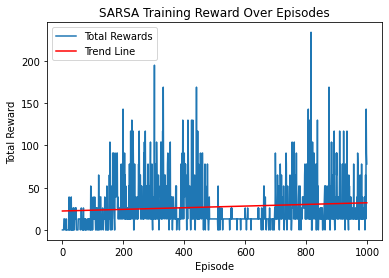

In [29]:
if __name__ == "__main__":
    env = MiniPongEnv(level=1, size=5, normalise=True)
    alpha = 0.01
    epsilon = 1.0
    gamma = 0.5
    num_episodes = 1000

    q_table = sarsa(env, alpha, epsilon, gamma, num_episodes)

In [30]:
print(q_table)
print(q_table.shape)

[[6.12873198e-05 1.56484044e-03 6.40611831e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [3.18833177e-04 1.26634922e-02 1.84532138e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.00946876e-04 4.37798239e-02 2.53002066e-04]
 [1.02510926e-03 9.24676093e-02 1.03714295e-03]
 [3.40811123e-03 1.59946373e-01 2.78601386e-03]
 [1.26624289e-02 2.99190674e-01 2.29662188e-03]
 [1.57510489e-02 3.52073577e-01 7.65975877e-03]
 [5.70063533e-02 5.42293935e-01 1.42377595e-02]
 [1.94953817e-01 8.09871155e-01 8.51404580e-02]
 [3.98814259e-01 1.20081894e+00 2.00647594e-01]
 [7.34970377e-01 5.67833102e-01 3.42127775e-01]
 [1.09063166e+00 4.79169990e-01 4.04812089e-01]
 [4.72749302e-01 2.70341923e-01 9.15879160e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.15971310e-01 6.34061317e-02 9.54145763e-01]
 [2.13358377e-02 6.12851516e-03 4.26362989e-01]
 [6.18492250e-03 5.13677997e-03 4.25050980e-01]
 [4.25525255e-03 1.49583427e-03 2.15763939e-01]
 [1.01524743e-03 1.40996529e-04 1.677823

### 4. After deciding the training is complete, run 50 test episodes using your trained policy with ϵ= 0.0 for all 50 episodes. Reset the environment at the beginning of each episode. Calculate the average of the sum of rewards per episode (call this the Test-Average) and the standard deviation (the Test-Standard-Deviation). These values indicate how your trained agent performs

In [31]:
def test_policy(env, q, epsilon=0.0, num_episodes=50):
    rewards = []  # List to store total rewards per episode
    start = time.time()
    for episode in range(num_episodes):
        state = env.reset()  # Reset environment for a new episode
        dz = state[0]  # Assume state is represented similarly as before
        current_state = encode_state(dz, num_states)  # Encode state

        total_reward = 0
        done = False
        while not done:
            action = choose(q, current_state, epsilon)  # Always choose the best action (greedy)
            next_state, reward, done, _ = env.step(action)
            next_dz = next_state[0]
            next_state_encoded = encode_state(next_dz, num_states)
            
            # Update state
            current_state = next_state_encoded
            total_reward += reward

        rewards.append(total_reward)  # Store the total reward for this episode

    # Calculate the mean and standard deviation of the rewards
    test_average = np.mean(rewards)
    test_std_deviation = np.std(rewards)
    end = time.time() - start
    # Output the performance
    print(f"Test-Average: {test_average:.2f}, Test-Standard-Deviation: {test_std_deviation:.2f}")
    print(f"SARSA Test time = {end}")
    # Plotting the performance
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, label='Rewards per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('SARSA Test Rewards Over 50 Episodes')
    plt.axhline(y=test_average, color='r', linestyle='-', label=f'Average Reward: {test_average:.2f}')
    plt.legend()
    plt.savefig('SARSA Test Reward Over Episodes')
    plt.show()

    return test_average, test_std_deviation


Test-Average: 58.24, Test-Standard-Deviation: 53.87
SARSA Test time = 0.14705395698547363


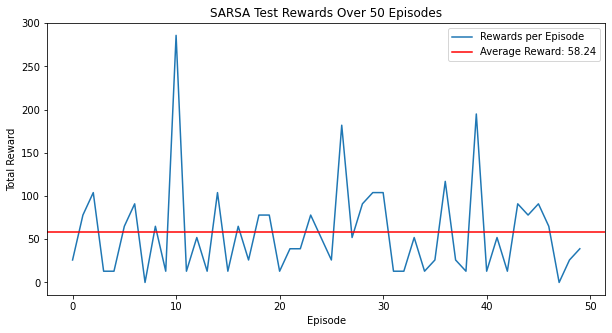

In [32]:
# Assuming 'env' is your environment and 'q' is the Q-table from training
test_average, test_std_deviation = test_policy(env, q_table)


## B. Q-learning using DQN (Deep learning method)

In [33]:
env = MiniPongEnv(level=1, size=5, normalise=True)

In [34]:
class DQN():
    ''' Deep Q Neural Network class. '''
    def __init__(self, state_dim, action_dim, hidden_dim=64, lr=0.01):
        self.criterion = torch.nn.MSELoss()
        self.model = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

    def update(self, state, y):
        """ Update the weights of the network given a training sample. """
        state_tensor = torch.Tensor([state])
        y_tensor = torch.Tensor([y])
        self.optimizer.zero_grad()
        y_pred = self.model(state_tensor)
        loss = self.criterion(y_pred, y_tensor)
        loss.backward()
        self.optimizer.step()

    def predict(self, state):
        """ Compute Q values for all actions using the DQL. """
        with torch.no_grad():
            return self.model(torch.Tensor([state]))

In [35]:
def plot_rewards(values, title='DQN on MiniPong', save=True):
    """ Plot the reward curve and histogram of results over time. """
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    fig.suptitle(title)
    
    # Plotting the reward per episode
    ax[0].plot(values, label='Reward per Episode')
    ax[0].set_xlabel('Episodes')
    ax[0].set_ylabel('Total Reward')

    # Calculating and plotting the trend line
    z = np.polyfit(range(len(values)), values, 1)  # Linear trend line
    p = np.poly1d(z)
    ax[0].plot(range(len(values)), p(range(len(values))), "r--", label='Trend Line')  # Add trend line to the plot
    
    ax[0].legend()
    
    # Histogram of the last 50 episodes
    ax[1].hist(values[-50:])
    ax[1].set_xlabel('Scores in Last 50 Episodes')
    ax[1].set_ylabel('Frequency')
    
    if save:
        plt.savefig(f'{title}.png')
    plt.show()

In [36]:
def q_learning(env, model, episodes, gamma=0.99, epsilon=1, eps_min=0.1, eps_decay=0.97, verbose=True):
    final_rewards = []
    start = time.time()
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                q_values = model.predict(state).squeeze()
                action = torch.argmax(q_values).item()

            next_state, reward, done, _ = env.step(action)
            total_reward += reward

            q_values = model.predict(state).squeeze().tolist()
            q_values_next = model.predict(next_state).squeeze()

            if not done:
                q_values[action] = reward + gamma * torch.max(q_values_next).item()
            else:
                q_values[action] = reward

            model.update(state, q_values)

            state = next_state

        epsilon = max(eps_min, epsilon * eps_decay)
        final_rewards.append(total_reward)

        if verbose and episode % 50 == 0:
            print(f'Episode {episode}: Total Reward = {total_reward}, Epsilon = {epsilon:.2f}')
    end = time.time() - start
    print(f"Qlearning training time = {end}")
    return final_rewards


/tmp/ipykernel_3178936/1976954427.py:25: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ../torch/csrc/utils/tensor_new.cpp:201.)
  return self.model(torch.Tensor([state]))


Episode 0: Total Reward = 0.0, Epsilon = 0.96
Episode 50: Total Reward = 13.0, Epsilon = 0.21
Episode 100: Total Reward = 39.0, Epsilon = 0.10
Episode 150: Total Reward = 0.0, Epsilon = 0.10
Episode 200: Total Reward = 13.0, Epsilon = 0.10
Episode 250: Total Reward = 13.0, Epsilon = 0.10
Episode 300: Total Reward = 13.0, Epsilon = 0.10
Episode 350: Total Reward = 0.0, Epsilon = 0.10
Episode 400: Total Reward = 13.0, Epsilon = 0.10
Episode 450: Total Reward = 0.0, Epsilon = 0.10
Episode 500: Total Reward = 13.0, Epsilon = 0.10
Episode 550: Total Reward = 0.0, Epsilon = 0.10
Episode 600: Total Reward = 13.0, Epsilon = 0.10
Episode 650: Total Reward = 0.0, Epsilon = 0.10
Episode 700: Total Reward = 0.0, Epsilon = 0.10
Episode 750: Total Reward = 52.0, Epsilon = 0.10
Episode 800: Total Reward = 39.0, Epsilon = 0.10
Episode 850: Total Reward = 13.0, Epsilon = 0.10
Episode 900: Total Reward = 13.0, Epsilon = 0.10
Episode 950: Total Reward = 13.0, Epsilon = 0.10
Episode 1000: Total Reward = 3

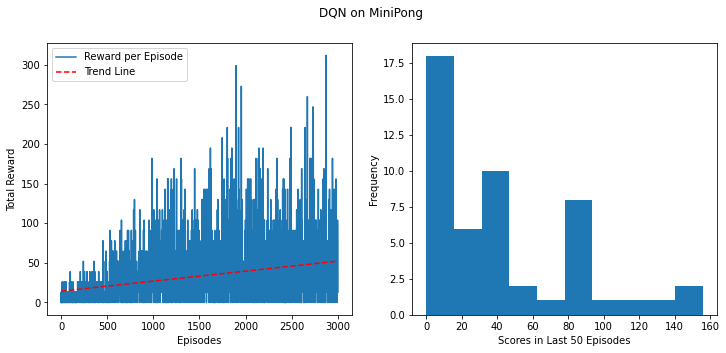

In [37]:
# Parameters
state_dim = 1  # Assuming single state dimension
action_dim = 3  # Actions: no move, move left, move right
hidden_dim = 64  # Simplified network due to small state space
lr = 5e-3
episodes = 3000  # Increased episodes for better training
gamma = 0.99  # Increased discount factor for better long-term rewards
eps_decay = 0.99
# Initialize environment and DQN model
env = MiniPongEnv(level=1, size=5, normalise=True)  # Assuming MiniPongEnv is defined elsewhere
dqn_model = DQN(state_dim, action_dim, hidden_dim, lr)

# Run Q-learning with DQN
rewards = q_learning(env, dqn_model, episodes, gamma, eps_decay)

# Plot the results
plot_rewards(rewards, title='DQN on MiniPong')


Test Episode 1/50, Total Reward: 0.0
Test Episode 11/50, Total Reward: 364.0
Test Episode 21/50, Total Reward: 39.0
Test Episode 31/50, Total Reward: 195.0
Test Episode 41/50, Total Reward: 39.0

Test-Average: 152.88
Test-Standard-Deviation: 163.56
DQN Qlearning test time = 1.0011537075042725


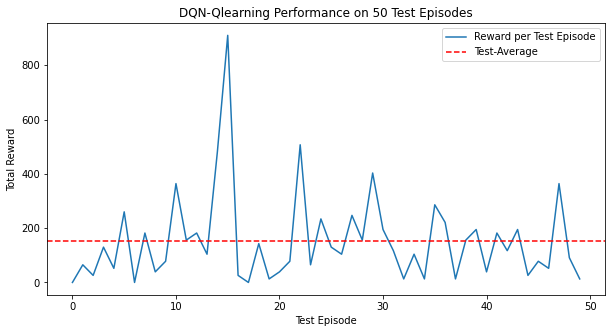

In [38]:
def test_dqn(env, model = dqn_model, num_episodes=50):
    """ Test the trained DQN model over multiple episodes. """
    total_rewards = []
    start = time.time()
    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            # Use the trained model to predict Q-values
            q_values = model.predict(state).squeeze()
            action = torch.argmax(q_values).item()  # Select action with highest Q-value

            # Take action in the environment
            next_state, reward, done, _ = env.step(action)
            total_reward += reward

            state = next_state

        total_rewards.append(total_reward)
        if episode % 10 == 0:
            print(f'Test Episode {episode+1}/{num_episodes}, Total Reward: {total_reward}')

    # Calculate average and standard deviation of rewards
    test_avg = np.mean(total_rewards)
    test_std = np.std(total_rewards)
    end = time.time() - start
    print(f"\nTest-Average: {test_avg:.2f}")
    print(f"Test-Standard-Deviation: {test_std:.2f}")
    print(f"DQN Qlearning test time = {end}")
    return total_rewards, test_avg, test_std
    
    
    
# Test the trained model
test_rewards, test_avg, test_std = test_dqn(env, dqn_model, num_episodes=50)

# Plot the test rewards
plt.figure(figsize=(10, 5))
plt.plot(test_rewards, label='Reward per Test Episode')
plt.axhline(test_avg, color='red', linestyle='--', label='Test-Average')
plt.xlabel('Test Episode')
plt.ylabel('Total Reward')
plt.title('DQN-Qlearning Performance on 50 Test Episodes')
plt.legend()
plt.savefig('DQN-Qlearning Performance on 50 Test Episodes')
plt.show()


### 5. (No programming required) Describe: In level 2 of MiniPong, the observed state would consist of 2 values instead of 1: it now contains the ball’s y-coordinate as well as the relative position dz (that we also get in level 1). Would this additional information help or hinder learning?

Adds the vertical position of the ball (y1), normalized to the scale of the environment. This gives the agent additional context about how high the ball is, along with its horizontal distance from the paddle.



## Task 4: Create an RL agent for MiniPong (level 3) In the level 3 version of the game, the observed state (the information available to the agent after each step) consists of three values: y, dx, and dz. These represent the following:

#### - y: the ball’s y-coordinate.
#### - dx: the change in the ball’s x-coordinate from the previous step to the current step.
#### - dz: the relative position of the ball to the centre of the paddle (same as in previous levels).

Similar to previous tasks, you can initialise MiniPong in two ways for this task: 

env = M i n i P o n g E n v ( level =3 , size =5 , normalise = True )

or

env = M i n i P o n g E n v ( level =3 , size =5 , normalise = False )

In the first version, step() returns normalised values for y and dz (between−1 and 1), while in
the second version these values are unnormalised. The dx values are always unnormalised (but
should be -1 or 1 in most cases, except after the paddle has been hit).
Steps
1. Create a neural network-based RL agent that finds a policy using all level 3 state information.
Tip: typical values for the learning rate α (e.g., when using Adam) range from 0.0001 to
0.01, and the discount factor γ typically ranges from 0.9 to 0.999.
2. Choose an algorithm (e.g., deep TD or deep policy gradient).
3. Train an agent that achieves a running reward >300.
4. Keep the model small to avoid long training times. Start with a single hidden layer and a
small number of units.
5. Write a description explaining your approach and its performance. If some (or all) of your
attempts are unsuccessful, describe what did not work and which changes made a diﬀerence.
What to submit:
- Submit the Python code for your solutions, and a description of your approach.
- In your report, describe your solution, mention the Test-Average and Test-Standard-
Deviation, and include the Training Reward plot as described above.
Tips
1. RL tasks can take time to show progress. If the agent is not learning, experiment with
learning rates. For Adam, start with values between 5e-3 (faster) and 1e-4 (slower).
2. Even if learning does not work as expected, use the task to demonstrate your own under-
standing. Describe the ideas you tried and submit your code, along with an explanation of
any issues encountered.

### 1. Create a neural network-based RL agent that finds a policy using all level 3 state information. Tip: typical values for the learning rate α (e.g., when using Adam) range from 0.0001 to 0.01, and the discount factor γ typically ranges from 0.9 to 0.999.

In [39]:
from mini_pong import MiniPongEnv
env = MiniPongEnv(level = 3, size =5 , normalise = True)

### 2. Choose an algorithm (e.g., deep TD or deep policy gradient).

### Deep Policy Gradient : Actor Critic Method

In [40]:
SavedAction = namedtuple('SavedAction', ['log_prob', 'value'])

class ActorCritic(nn.Module):
    def __init__(self, ninputs, noutputs, gamma=0.99, lr=5e-3):
        super(ActorCritic, self).__init__()
        self.fc1 = nn.Linear(ninputs, 128)
        self.actor = nn.Linear(128, noutputs)
        self.critic = nn.Linear(128, 1)
        self.optimizer = optim.Adam(self.parameters(), lr=5e-3)
        self.gamma = gamma
        self.saved_actions = []
        self.rewards = []
        self.eps = np.finfo(np.float32).eps.item()

    def forward(self, x):
        x = F.relu(self.fc1(x))
        action_prob = F.softmax(self.actor(x), dim=-1)
        state_values = self.critic(x)
        return action_prob, state_values
    
    def select_action(self, state):
        # Clipping or normalizing the state could go here if necessary
        # Example: state = np.clip(state, a_min=-1, a_max=1)  # If normalization bounds are known

        state = torch.from_numpy(state).float()
        probs, state_value = self.forward(state)
        m = Categorical(probs)
        action = m.sample()
        self.saved_actions.append(SavedAction(m.log_prob(action), state_value))
        return action.item()

    def update(self):
        R = 0
        returns = []
        for r in self.rewards[::-1]:
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + self.eps)
        loss = 0
        for (log_prob, value), R in zip(self.saved_actions, returns):
            advantage = R - value.item()
            policy_loss = -log_prob * advantage
            value_loss = F.smooth_l1_loss(value, torch.tensor([R]))
            loss += (policy_loss + value_loss)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        del self.rewards[:]
        del self.saved_actions[:]


Episode 1000: Last reward: 26.00, Average reward: 28.07
Episode 2000: Last reward: 52.00, Average reward: 47.88
Episode 3000: Last reward: 13.00, Average reward: 51.31
Episode 4000: Last reward: 26.00, Average reward: 34.86
Episode 5000: Last reward: 26.00, Average reward: 43.53
Episode 6000: Last reward: 377.00, Average reward: 226.56
Episode 7000: Last reward: 39.00, Average reward: 222.30
Episode 8000: Last reward: 377.00, Average reward: 233.44
Solved in 13min, running reward: 309.77


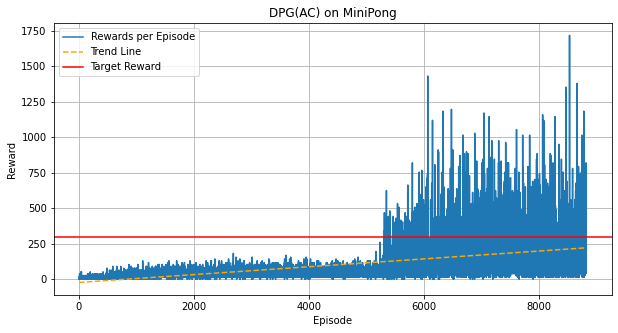

In [41]:
# Neural network settings
ninputs = env.observation_space.shape[0]
noutputs = env.action_space.n
PGDpolicy = ActorCritic(ninputs, noutputs, lr=5e-2, gamma = 0.95)

# Define a directory to save models
checkpoint_dir = "./model_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

def save_model(state, filename="checkpoint.pth"):
    torch.save(state, os.path.join(checkpoint_dir, filename))

def plot_rewards(rewards, title='DPG(AC) on MiniPong', targetreward=300):
    plt.figure(figsize=(10, 5))
    
    # Plot the rewards per episode
    plt.plot(rewards, label='Rewards per Episode')
    
    # Calculate and plot the trend line
    episodes = np.arange(len(rewards))
    z = np.polyfit(episodes, rewards, 1)  # Linear trend line
    trend = np.poly1d(z)
    plt.plot(episodes, trend(episodes), "orange", label='Trend Line', linestyle='--')
    
    # Plot the target reward line
    plt.axhline(y=targetreward, color='red', linestyle='-', label='Target Reward')
    
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{title}.png')
    plt.show()    
    

def train_minipong(env, policy, render=False, targetreward = 300,log_interval=1000, finalrender=False):
    starttime = time.time()
    running_reward = 0
    rewards = []

    # Training loop
    for i_episode in count(1):
        state = env.reset()
        ep_reward = 0

        try:
            for t in range(1, 10000):
                action = policy.select_action(state)
                next_state, reward, done, info = env.step(action)
                reward = float(reward)
                if render:
                    env.render()
                policy.rewards.append(reward)
                ep_reward += reward
                state = next_state  # Make sure to update the state
                if done:
                    break
        except Exception as e:
            print(f"Exception occurred during training: {e}")
            continue

        running_reward = 0.05 * ep_reward + 0.95 * running_reward
        policy.update()

        if i_episode % log_interval == 0:
            print(f'Episode {i_episode}: Last reward: {ep_reward:.2f}, Average reward: {running_reward:.2f}')
            save_model({
                'episode': i_episode,
                'model_state_dict': policy.state_dict(),
                'optimizer_state_dict': policy.optimizer.state_dict(),
                'running_reward': running_reward
            })

        if running_reward > targetreward:
            print(f"Solved in {int((time.time() - starttime) / 60)}min, running reward: {running_reward:.2f}")
            break

        rewards.append(ep_reward)  # Track rewards for plotting

    # Optionally render a final episode
    if finalrender:
        state = env.reset()
        env.render()
        while True:
            action = policy.select_action(state)
            state, reward, done, info = env.step(action)
            env.render()
            if done:
                break

    plot_rewards(rewards)  # Plot the rewards after training

torch.save(PGDpolicy.state_dict(), './model_checkpoints/final_model.pth')

train_minipong(env, PGDpolicy)

Test Episode 1/50, Total Reward: 130.0
Test Episode 11/50, Total Reward: 52.0
Test Episode 21/50, Total Reward: 156.0
Test Episode 31/50, Total Reward: 598.0
Test Episode 41/50, Total Reward: 13.0

Test-Average: 227.76
Test-Standard-Deviation: 185.17
PGD test time = 5.99221658706665


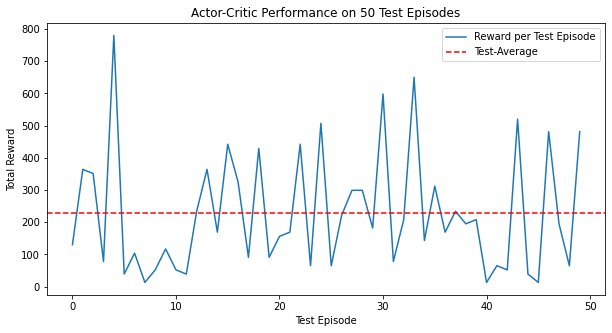

In [42]:
def test_actor_critic(env, model, num_episodes=50):
    """ Test the trained Actor-Critic model over multiple episodes. """
    total_rewards = []
    start = time.time()
    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = model.select_action(state)  # Actor-Critic selects action
            state, reward, done, _ = env.step(action)
            total_reward += reward

        total_rewards.append(total_reward)
        if episode % 10 == 0:
            print(f'Test Episode {episode+1}/{num_episodes}, Total Reward: {total_reward}')

    # Calculate average and standard deviation of rewards
    test_avg = np.mean(total_rewards)
    test_std = np.std(total_rewards)
    end = time.time() - start
    print(f"\nTest-Average: {test_avg:.2f}")
    print(f"Test-Standard-Deviation: {test_std:.2f}")
    print(f"PGD test time = {end}")
    return total_rewards, test_avg, test_std

# Example usage of the testing function, assuming `model` is your Actor-Critic model
test_rewards, test_avg, test_std = test_actor_critic(env, PGDpolicy, num_episodes=50)

# Plot the test rewards
plt.figure(figsize=(10, 5))
plt.plot(test_rewards, label='Reward per Test Episode')
plt.axhline(test_avg, color='red', linestyle='--', label='Test-Average')
plt.xlabel('Test Episode')
plt.ylabel('Total Reward')
plt.title('Actor-Critic Performance on 50 Test Episodes')
plt.legend()
plt.savefig(f'Actor-Critic Performance on 50 Test Episodes.png')
plt.show()

# Bonus Questions

## Bonus questions (extra points)
### 1. I can do it (Neural Networks): Train a neural network to predict the dz variable from the input images.

In [43]:
# Calculate dz from the correct number of labels
x_positions = trainLabels[:, 0]  # Assuming x is in the first column
z_positions = trainLabels[:, 2]  # Assuming z is in the third column
dz = x_positions - (z_positions * 3 + 1)

# Convert to tensors
trainPixTensor = torch.tensor(trainPix.copy(), dtype=torch.float32).reshape(-1, 1, 15, 15)
dzTensor = torch.tensor(dz, dtype=torch.float32).unsqueeze(1)

# Create TensorDataset and DataLoader
trainDataset = TensorDataset(trainPixTensor, dzTensor)
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)

# Check if shapes are now aligned
print(f"Tensor shape of trainPixTensor: {trainPixTensor.shape}")
print(f"Tensor shape of dzTensor: {dzTensor.shape}")


Tensor shape of trainPixTensor: torch.Size([676, 1, 15, 15])
Tensor shape of dzTensor: torch.Size([676, 1])


In [44]:
class MiniPongCNN(nn.Module):
    def __init__(self):
        super(MiniPongCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(32 * 3 * 3, 120)  # Adjusted to 32 channels * 3 * 3 grid size
        self.fc2 = nn.Linear(120, 1)  # Output one value for dz

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        return self.fc2(x)



# Instantiate the model, loss function, and optimizer
model = MiniPongCNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.train()

# Training the model
num_epochs = 200
for epoch in range(num_epochs):
    total_loss = 0
    for inputs, labels in trainLoader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(trainLoader)}')


Epoch 1/200, Loss: 30.77516607804732
Epoch 2/200, Loss: 23.41556419025768
Epoch 3/200, Loss: 19.251419154080477
Epoch 4/200, Loss: 13.431551716544412
Epoch 5/200, Loss: 5.730302756482905
Epoch 6/200, Loss: 3.8034905086864126
Epoch 7/200, Loss: 2.9014171145179053
Epoch 8/200, Loss: 1.6845849048007617
Epoch 9/200, Loss: 0.9917570162903179
Epoch 10/200, Loss: 0.6102898073467341
Epoch 11/200, Loss: 0.4579344059933316
Epoch 12/200, Loss: 0.3890157775445418
Epoch 13/200, Loss: 0.35517521744424646
Epoch 14/200, Loss: 0.28849099068479106
Epoch 15/200, Loss: 0.289240464060144
Epoch 16/200, Loss: 0.23837962272492322
Epoch 17/200, Loss: 0.20637259090488608
Epoch 18/200, Loss: 0.19301532937044447
Epoch 19/200, Loss: 0.1810893216593699
Epoch 20/200, Loss: 0.1628313013775782
Epoch 21/200, Loss: 0.15442315421321176
Epoch 22/200, Loss: 0.13694897006181153
Epoch 23/200, Loss: 0.12888978235423565
Epoch 24/200, Loss: 0.12036156078631227
Epoch 25/200, Loss: 0.12354479188268835
Epoch 26/200, Loss: 0.099570

In [45]:
# Calculate dz for testing set assuming testLabels already has x and z loaded
x_positions_test = testLabels[:, 0]
z_positions_test = testLabels[:, 2]
dz_test = x_positions_test - (z_positions_test * 3 + 1)

# Convert to tensors
testPixTensor = torch.tensor(testPix.copy(), dtype=torch.float32).reshape(-1, 1, 15, 15)
dzTestTensor = torch.tensor(dz_test, dtype=torch.float32).unsqueeze(1)

# Create testing dataset and loader
testDataset = TensorDataset(testPixTensor, dzTestTensor)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=False)

In [46]:
model.eval()  # Switch to evaluation mode, which turns off dropout and batch normalization

total_loss = 0.0
total_samples = 0
criterion = nn.MSELoss()  # Assuming MSE is your loss criterion

# No gradient calculation is needed
with torch.no_grad():
    for inputs, labels in testLoader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * inputs.size(0)  # Multiply by batch size to accumulate properly
        total_samples += inputs.size(0)

average_loss = total_loss / total_samples
print(f'Average Loss on Test Set: {average_loss:.4f}')


Average Loss on Test Set: 0.0552


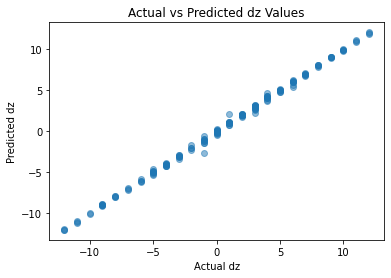

In [47]:
predictions, actuals = [], []
with torch.no_grad():
    for inputs, labels in testLoader:
        outputs = model(inputs)
        predictions.extend(outputs.view(-1).tolist())
        actuals.extend(labels.view(-1).tolist())

# Plotting predictions against actuals can give you a good visual indicator of performance
import matplotlib.pyplot as plt

plt.scatter(actuals, predictions, alpha=0.5)
plt.xlabel('Actual dz')
plt.ylabel('Predicted dz')
plt.title('Actual vs Predicted dz Values')
plt.show()

### 2. Bring it on (Pong level 3): Modify the learning process or adjust the reward structure in the environment to discourage the agent from moving the paddle unnecessarily. Compare the learned policies before and after your changes.

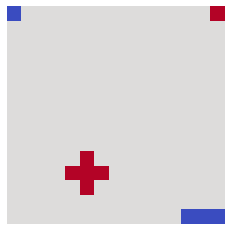

State: [-0.61538462], Reward: -0.5, Done: False, Total Reward: -0.5


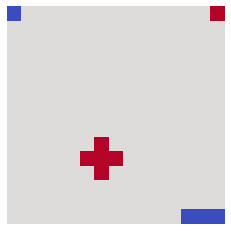

State: [-0.53846154], Reward: 0, Done: False, Total Reward: -0.5


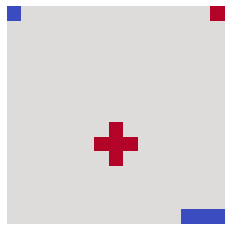

State: [-0.46153846], Reward: -0.5, Done: False, Total Reward: -1.0


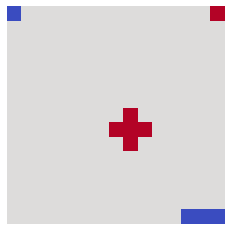

State: [-0.38461538], Reward: 0, Done: False, Total Reward: -1.0


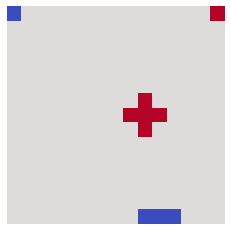

State: [-0.07692308], Reward: 0, Done: False, Total Reward: -1.0


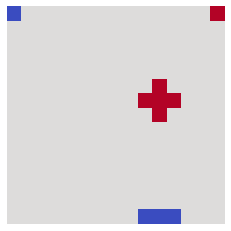

State: [0.], Reward: 0, Done: False, Total Reward: -1.0


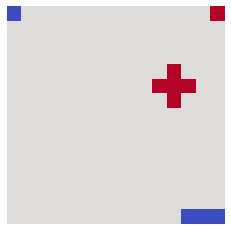

State: [-0.15384615], Reward: -0.5, Done: False, Total Reward: -1.5


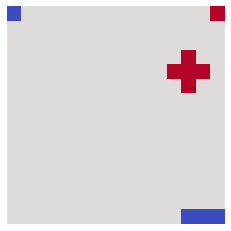

State: [-0.07692308], Reward: 0, Done: False, Total Reward: -1.5


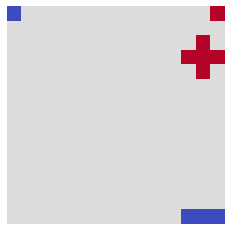

State: [0.], Reward: 0, Done: False, Total Reward: -1.5


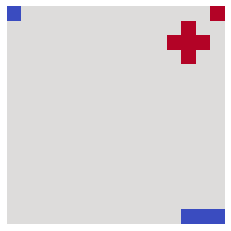

State: [-0.07692308], Reward: 0, Done: False, Total Reward: -1.5


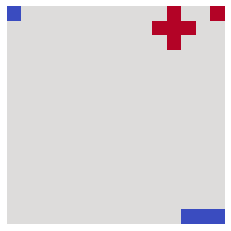

State: [-0.15384615], Reward: -0.5, Done: False, Total Reward: -2.0


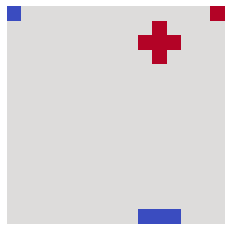

State: [0.], Reward: 0, Done: False, Total Reward: -2.0


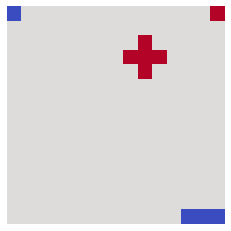

State: [-0.30769231], Reward: -0.5, Done: False, Total Reward: -2.5


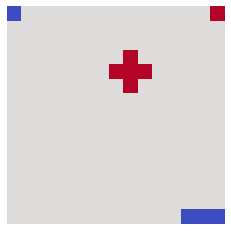

State: [-0.38461538], Reward: 0, Done: False, Total Reward: -2.5


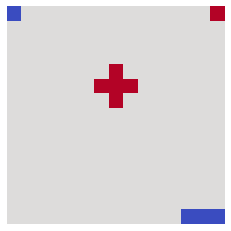

State: [-0.46153846], Reward: -0.5, Done: False, Total Reward: -3.0


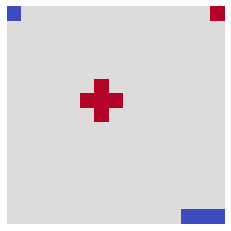

State: [-0.53846154], Reward: -0.5, Done: False, Total Reward: -3.5


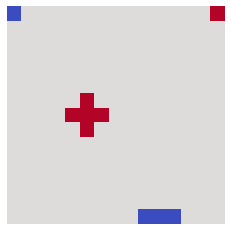

State: [-0.38461538], Reward: -0.5, Done: False, Total Reward: -4.0


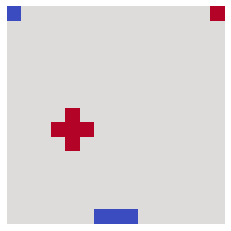

State: [-0.23076923], Reward: -0.5, Done: False, Total Reward: -4.5


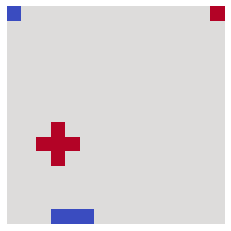

State: [-0.07692308], Reward: 0, Done: False, Total Reward: -4.5


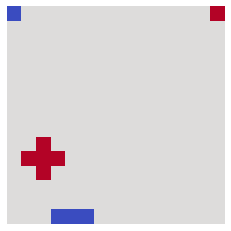

State: [-0.15384615], Reward: 0, Done: False, Total Reward: -4.5


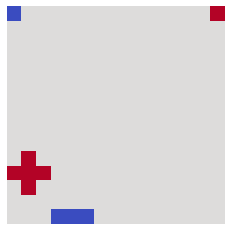

State: [-0.23076923], Reward: 0, Done: False, Total Reward: -4.5


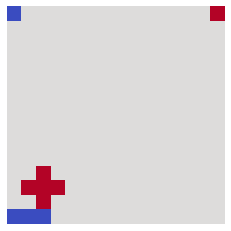

State: [0.07692308], Reward: 26, Done: False, Total Reward: 21.5


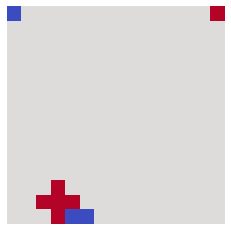

State: [-0.07692308], Reward: -10, Done: True, Total Reward: 11.5


In [48]:
class SimpleAgent:
    def __init__(self, action_space):
        self.action_space = action_space
    
    def predict(self, state):
        # Simple random action policy for demonstration
        return self.action_space.sample()

class ModifiedMiniPongEnv(MiniPongEnv):
    def __init__(self, level=3, size=5, normalise=True):
        super().__init__(level, size, normalise)
        self.last_action = None  # To track the last action taken

    def step(self, action):
        # Call the parent class's step function
        observation, reward, done, info = super().step(action)
        self.last_action = action  # Update the last action taken
        return observation, self.custom_reward(reward, done, action), done, info

    def custom_reward(self, reward, done, action):
        x, y, z, dx, dy = self.s1

        # Higher penalty if the game ends without hitting the ball
        if done:
            return -10  # Increased penalty for letting the ball pass

        # Reward for hitting the ball with the paddle
        if reward > 0:
            return reward + self.xymax  # Increased reward to emphasize hitting the ball

        # Penalty for moving the paddle unnecessarily
        if (action == 1 or action == 2) and not (x >= z * 3 and x < (z + 1) * 3):
            return -0.5  # Smaller penalty for unnecessary movement

        return 0  # No change for other situations

    def reset(self):
        # Ensure the last action is reset at the start of each episode
        self.last_action = None
        return super().reset()

# Example of using the modified environment
if __name__ == "__main__":
    env = ModifiedMiniPongEnv(level=1, size=5, normalise = True)
    agent = SimpleAgent(env.action_space)  # Initialize the agent with the action space
    state = env.reset()
    done = False
    total_reward = 0
    epsilon = 1.0  # Initial epsilon for exploration
    epsilon_decay = 0.995
    min_epsilon = 0.01

    while not done:
        if random.random() < epsilon:
            action = env.action_space.sample()  # Explore: random action
        else:
            action = agent.predict(state)  # Exploit: agent's action based on policy

        state, reward, done, _ = env.step(action)
        env.render()
        total_reward += reward
        print(f"State: {state}, Reward: {reward}, Done: {done}, Total Reward: {total_reward}")

        # Decay epsilon
        if epsilon > min_epsilon:
            epsilon *= epsilon_decay


Episode 500: Last reward: -11.50, Average reward: 13.10
Episode 1000: Last reward: 12.50, Average reward: 41.64
Episode 1500: Last reward: 37.50, Average reward: 46.40
Episode 2000: Last reward: 81.00, Average reward: 78.91
Episode 2500: Last reward: 66.50, Average reward: 123.03
Solved in 2min, running reward: 355.56


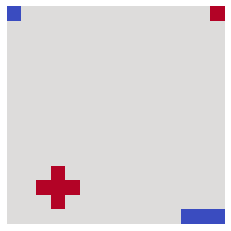

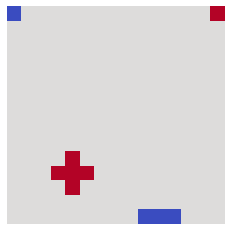

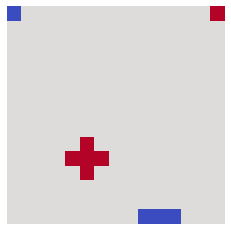

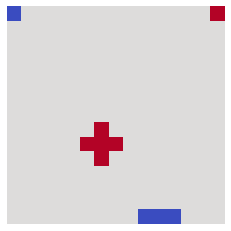

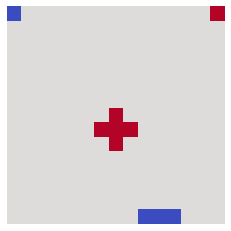

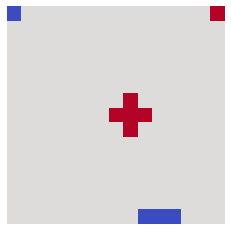

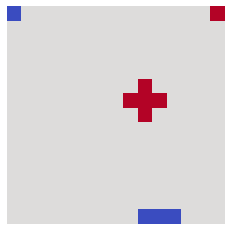

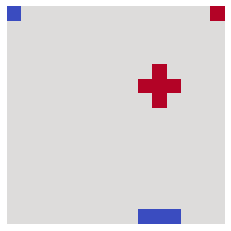

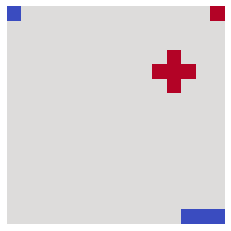

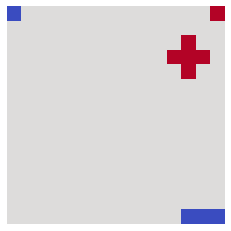

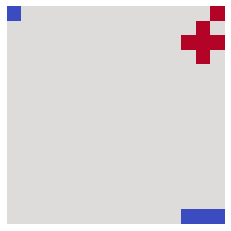

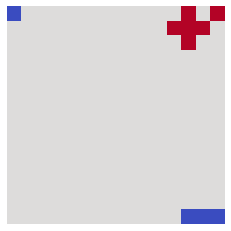

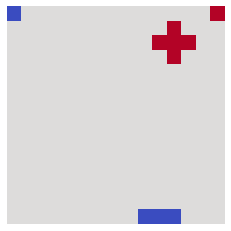

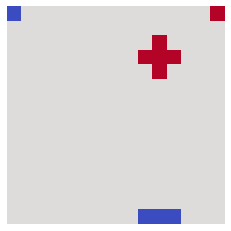

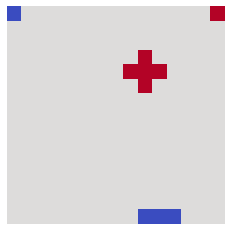

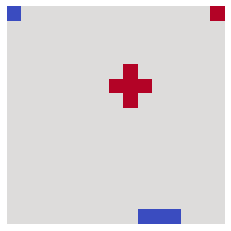

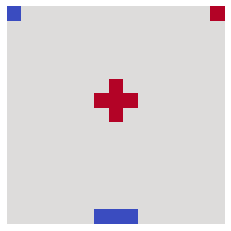

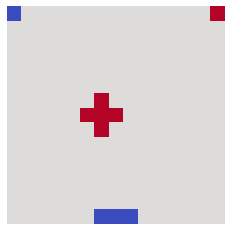

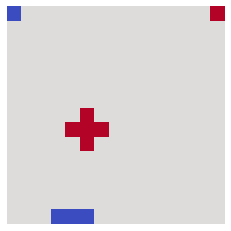

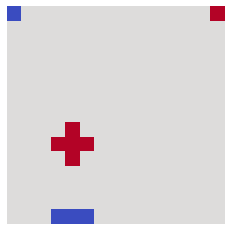

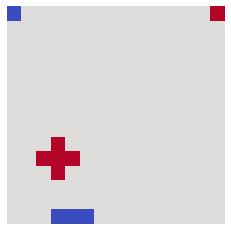

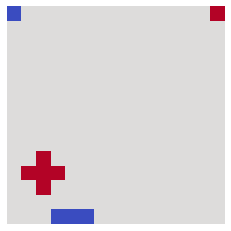

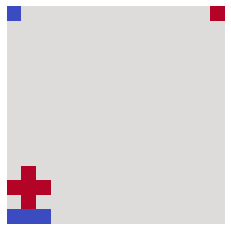

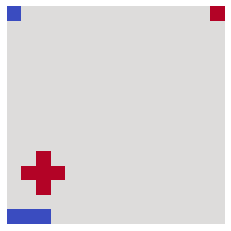

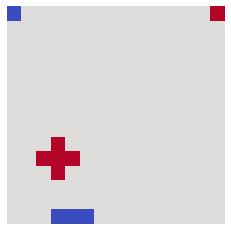

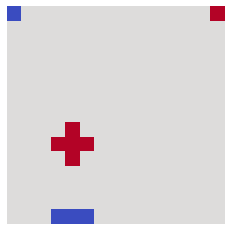

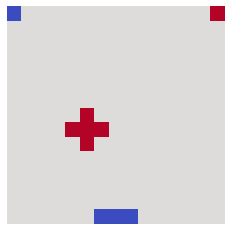

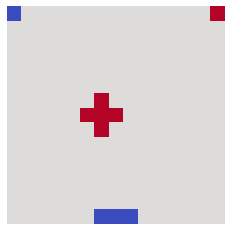

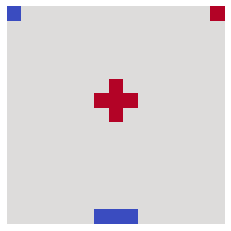

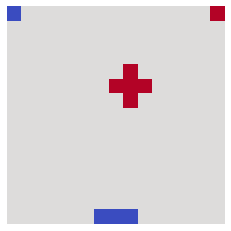

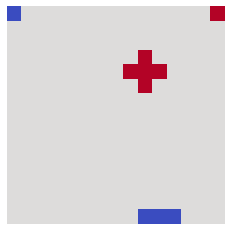

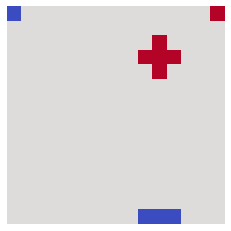

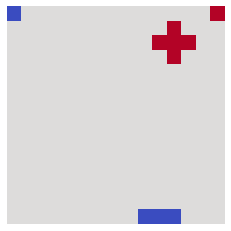

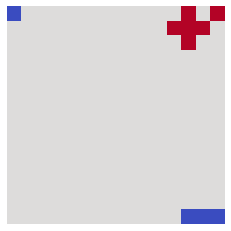

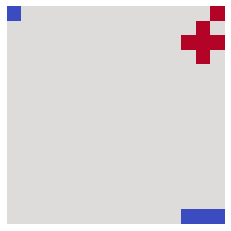

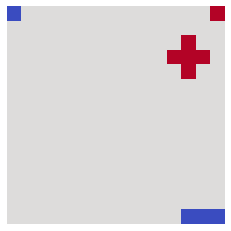

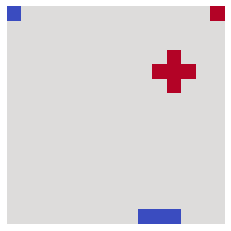

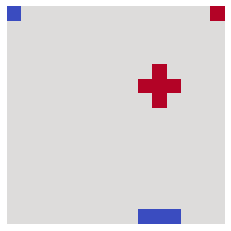

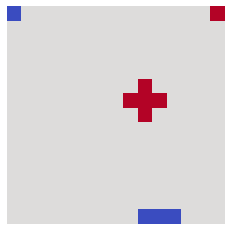

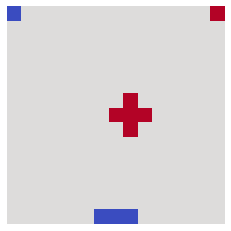

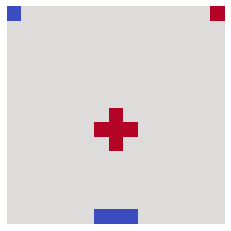

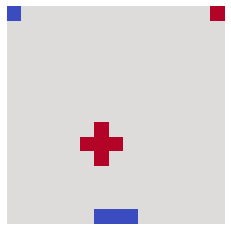

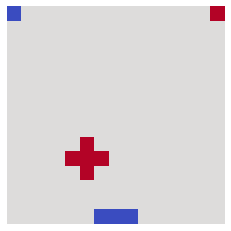

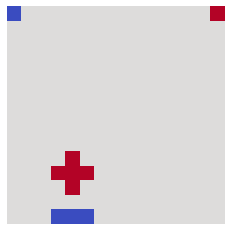

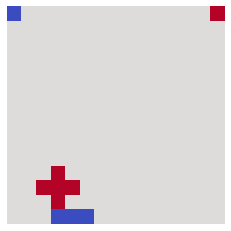

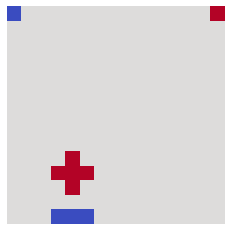

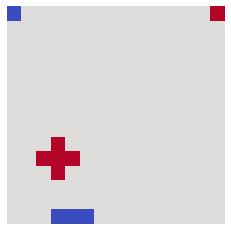

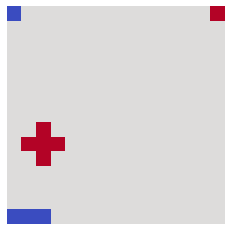

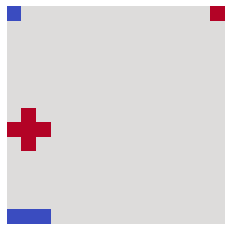

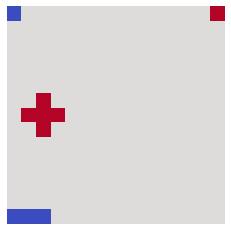

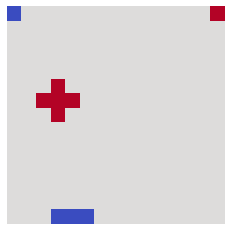

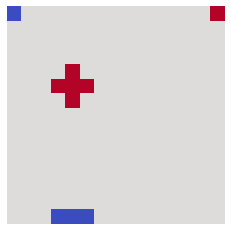

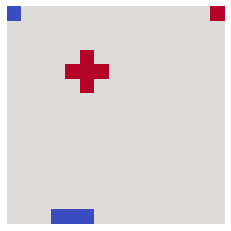

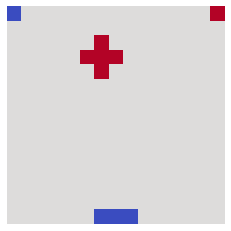

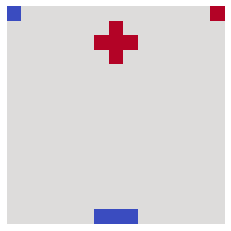

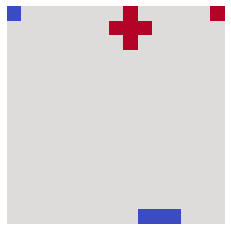

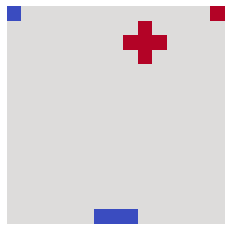

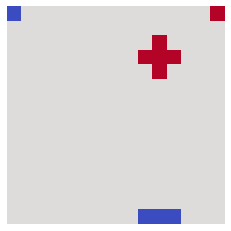

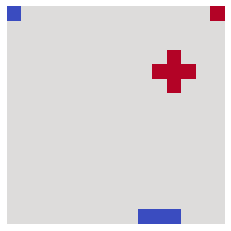

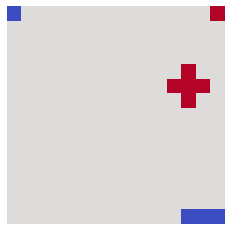

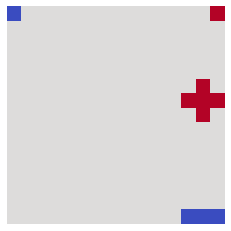

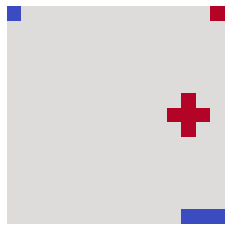

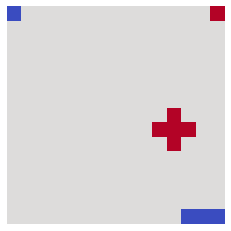

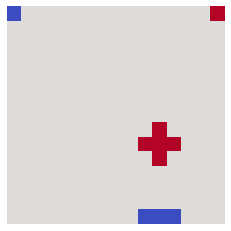

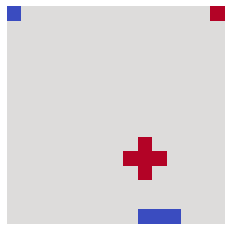

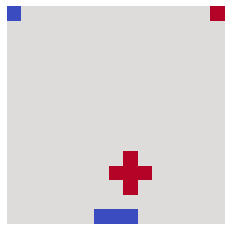

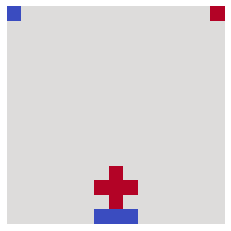

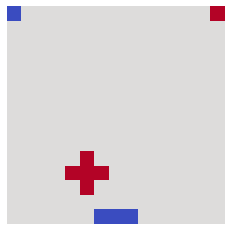

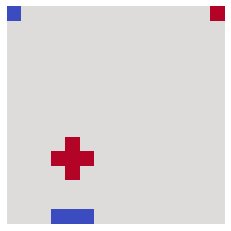

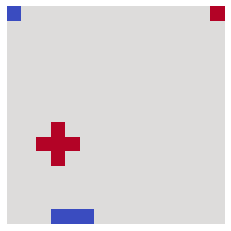

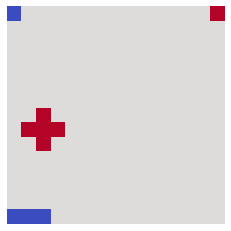

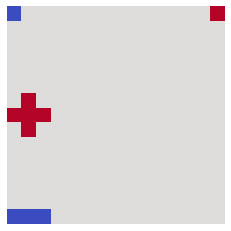

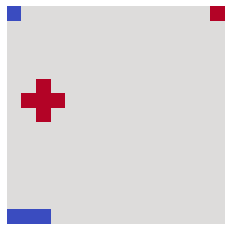

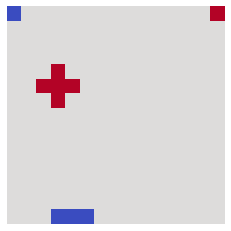

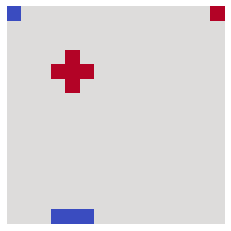

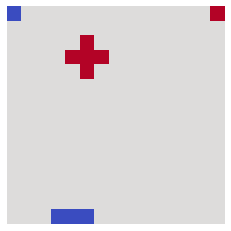

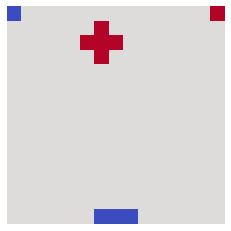

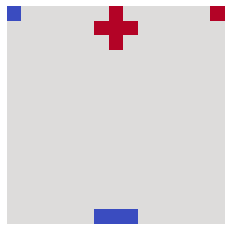

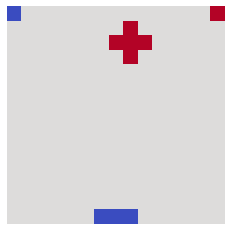

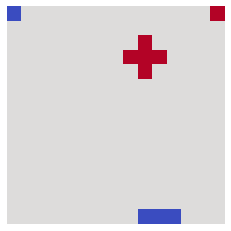

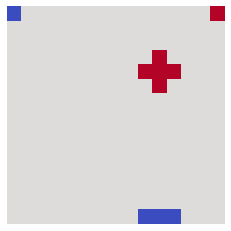

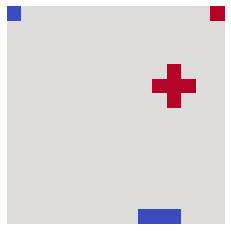

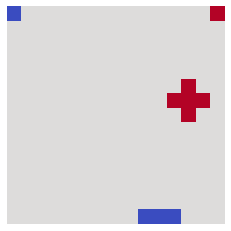

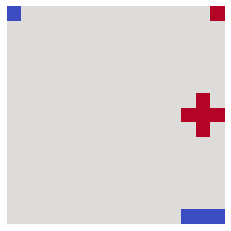

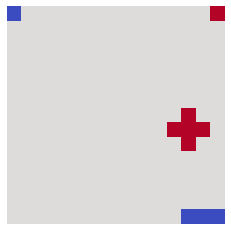

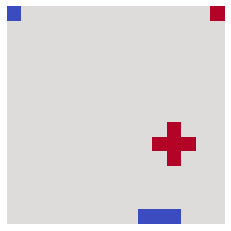

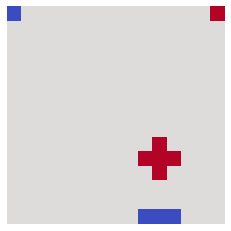

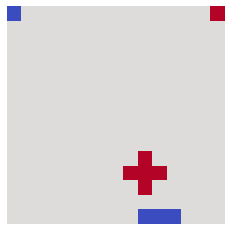

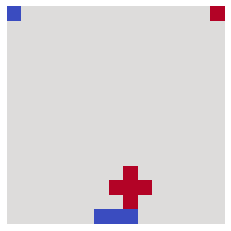

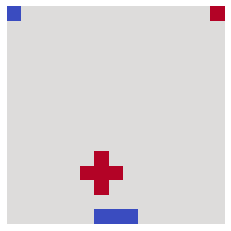

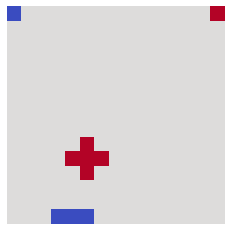

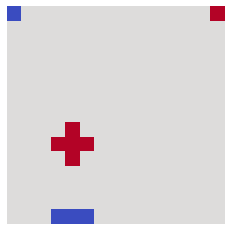

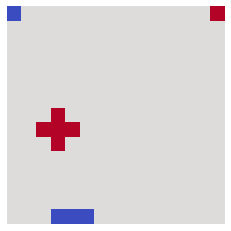

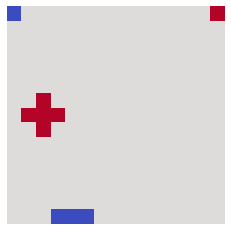

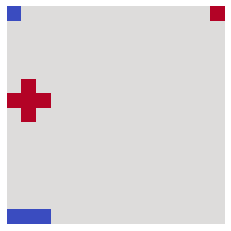

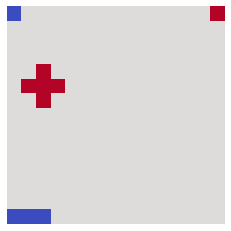

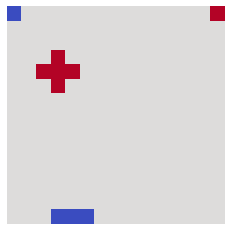

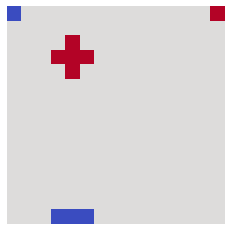

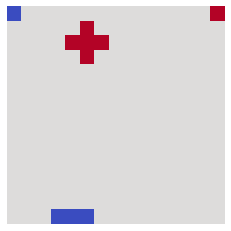

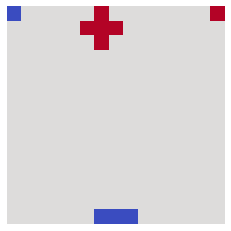

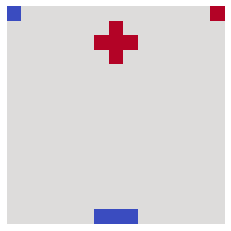

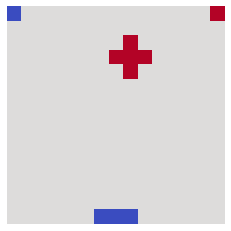

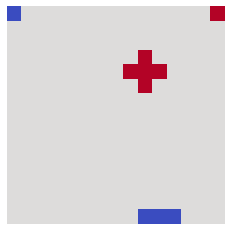

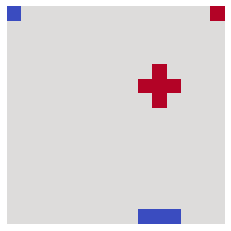

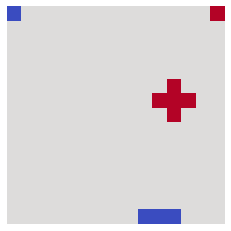

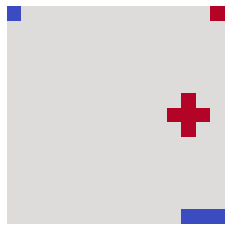

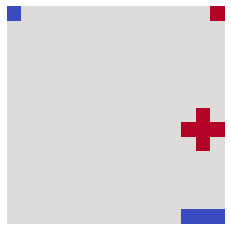

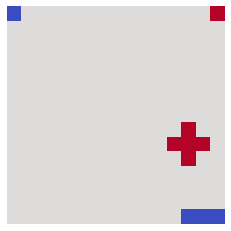

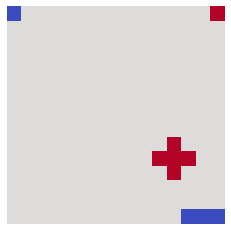

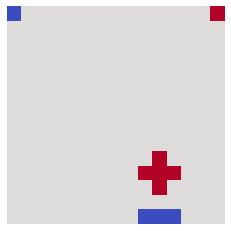

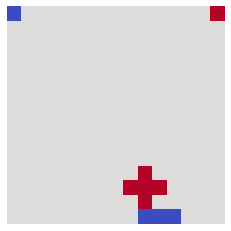

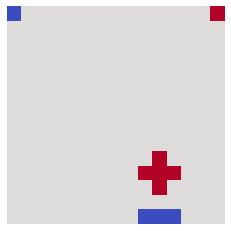

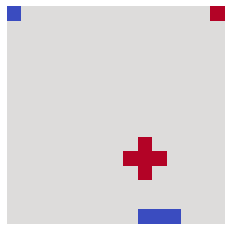

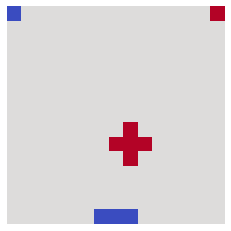

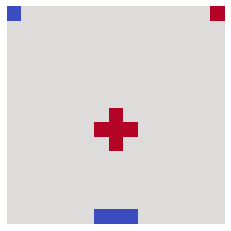

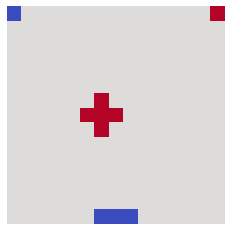

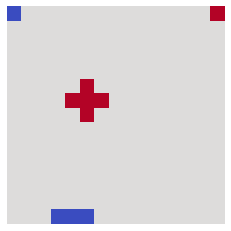

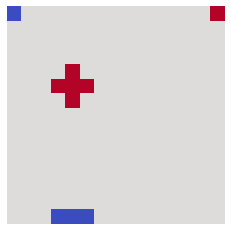

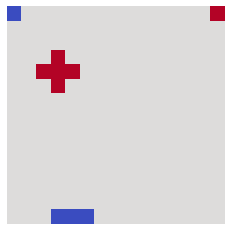

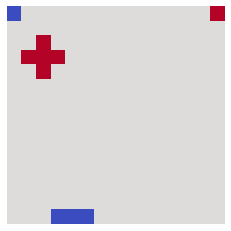

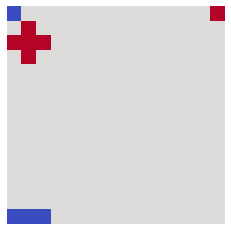

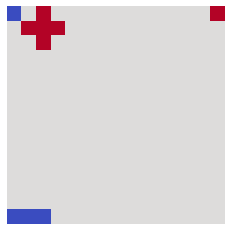

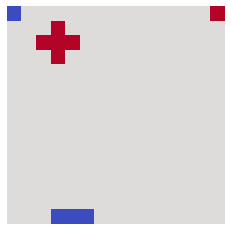

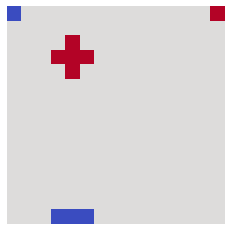

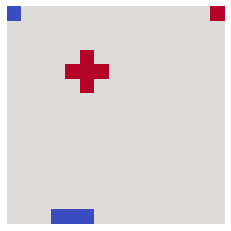

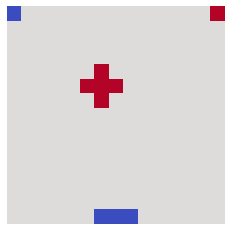

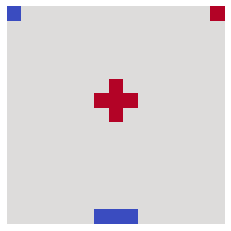

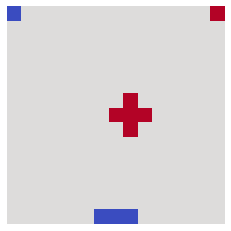

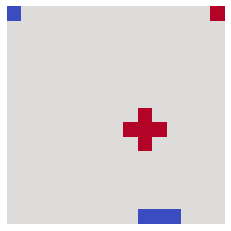

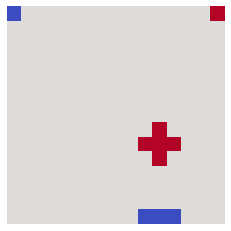

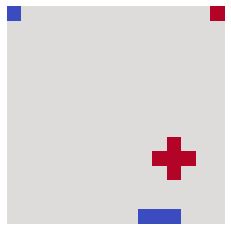

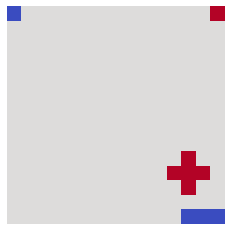

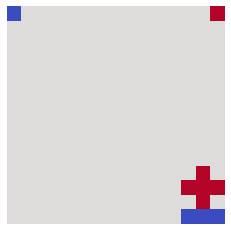

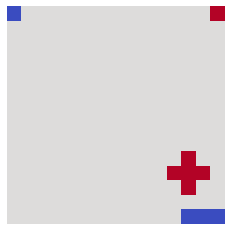

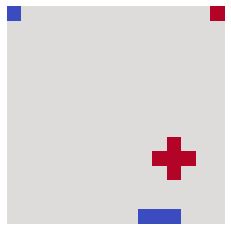

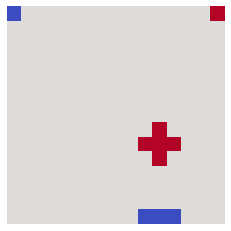

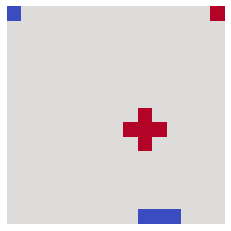

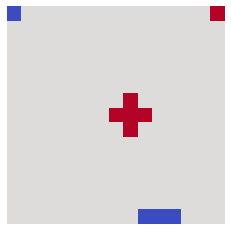

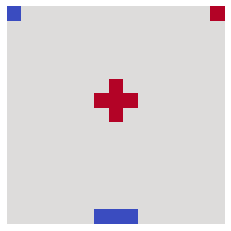

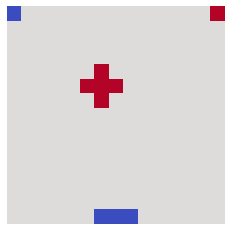

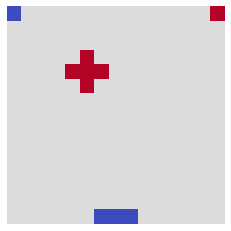

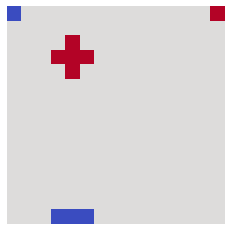

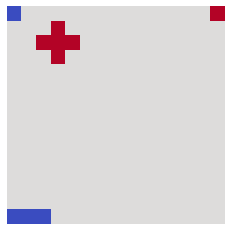

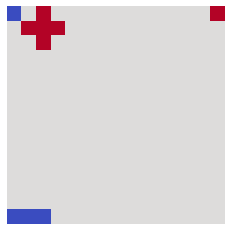

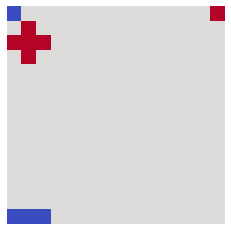

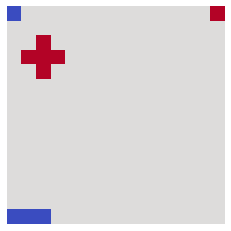

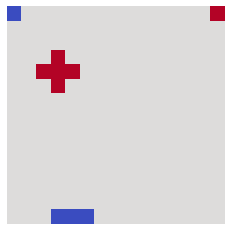

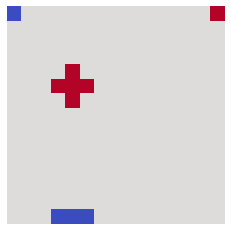

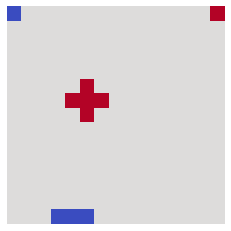

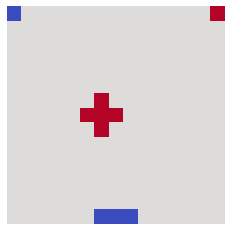

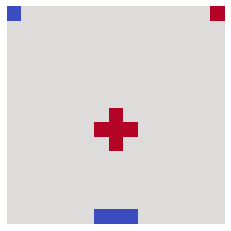

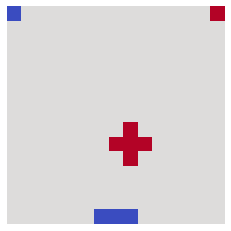

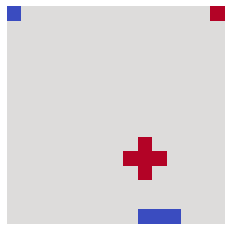

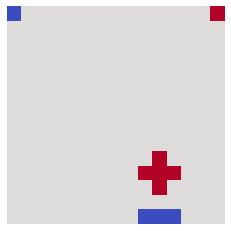

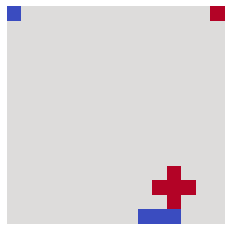

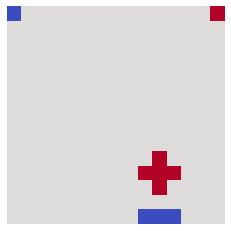

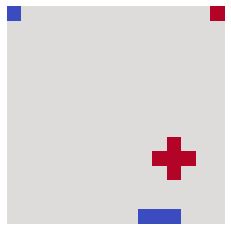

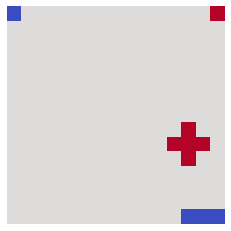

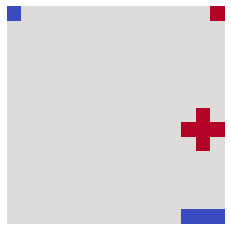

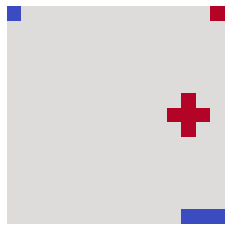

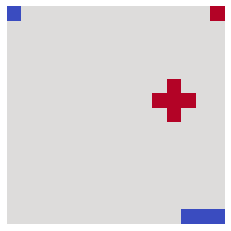

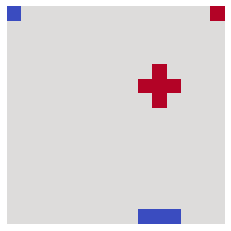

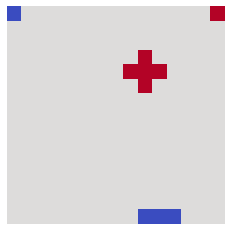

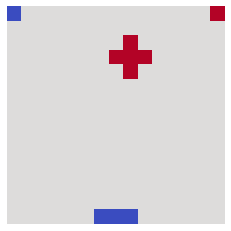

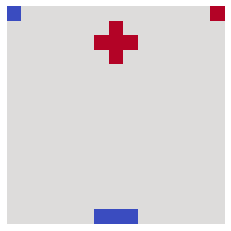

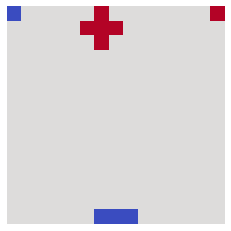

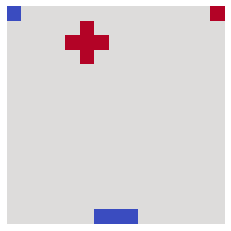

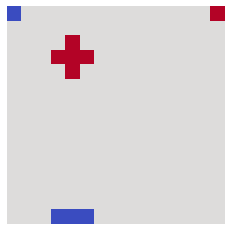

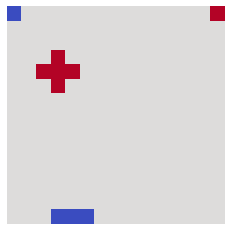

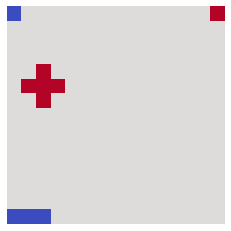

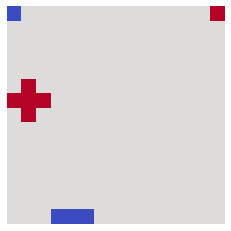

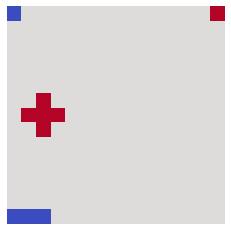

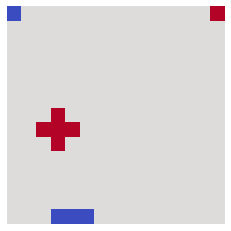

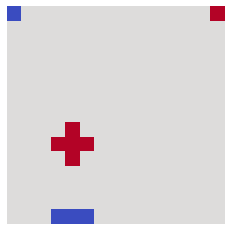

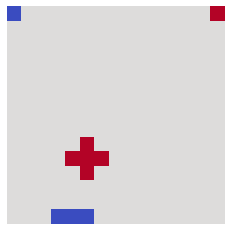

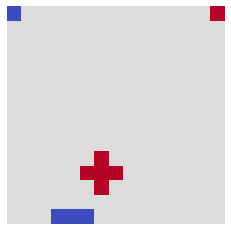

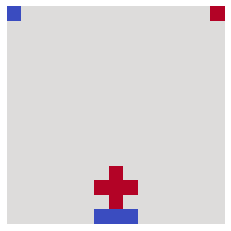

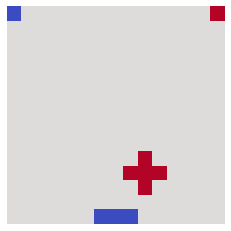

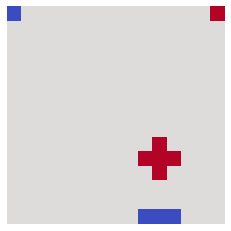

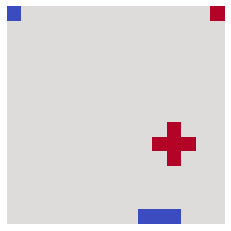

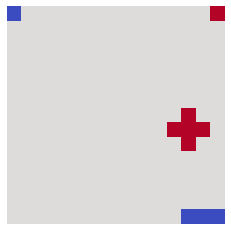

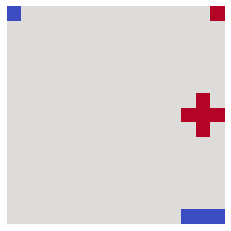

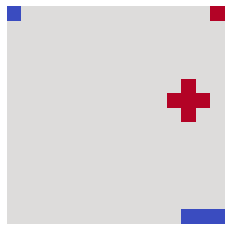

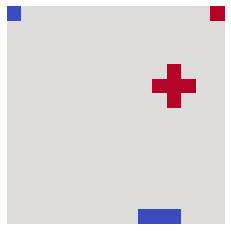

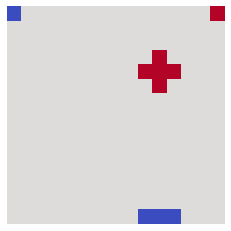

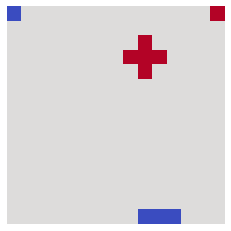

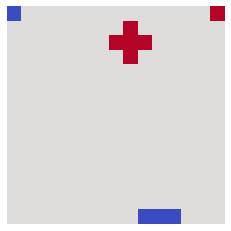

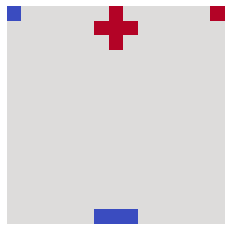

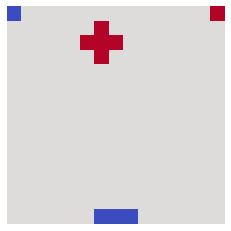

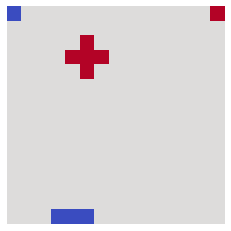

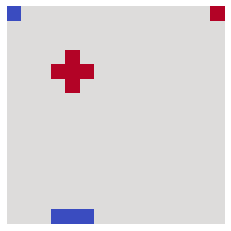

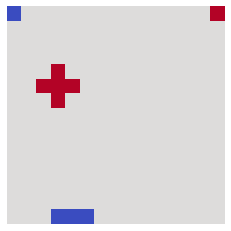

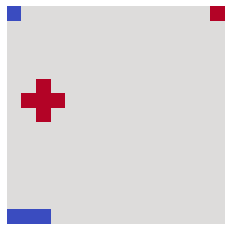

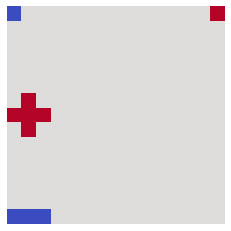

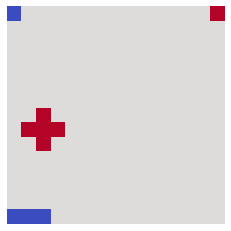

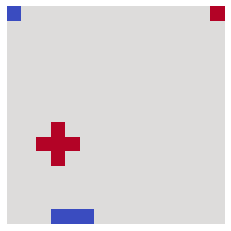

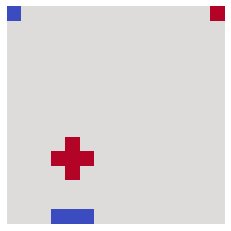

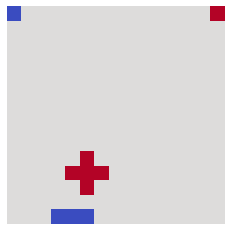

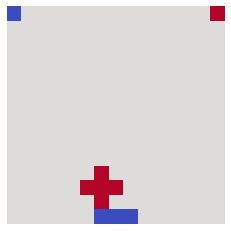

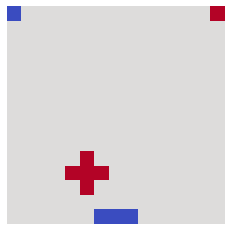

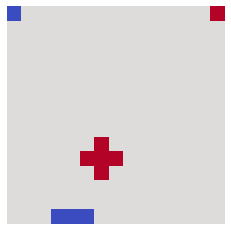

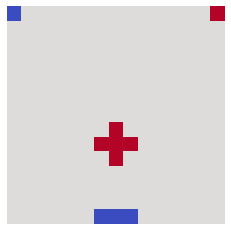

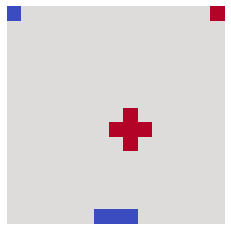

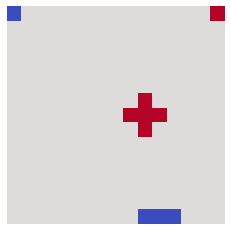

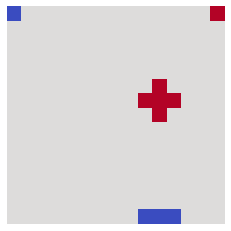

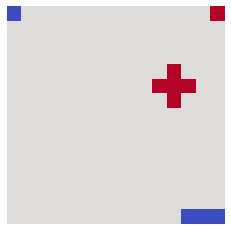

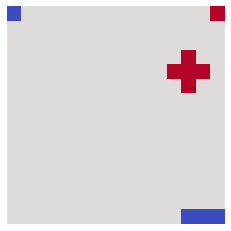

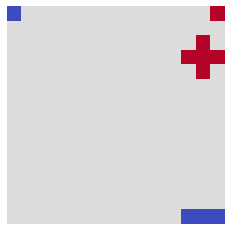

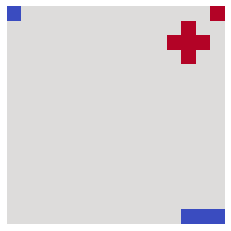

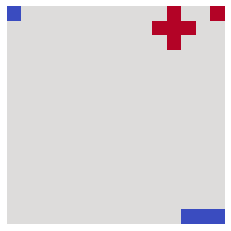

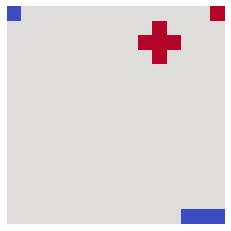

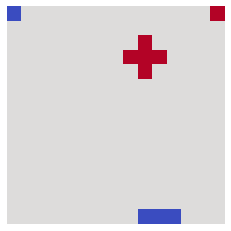

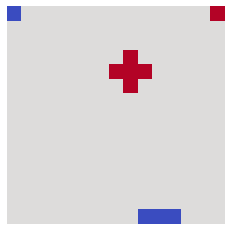

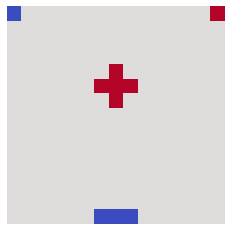

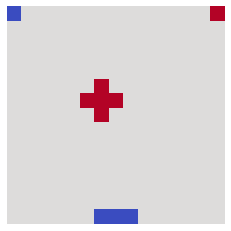

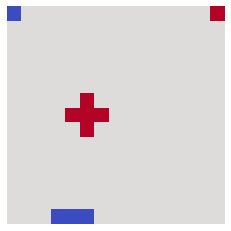

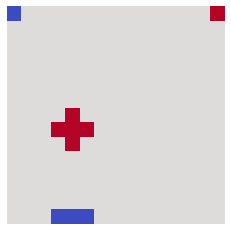

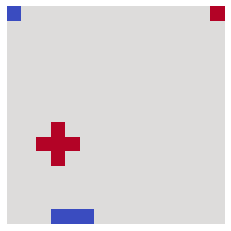

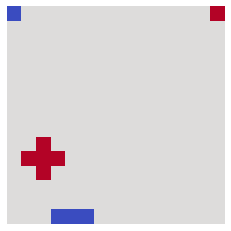

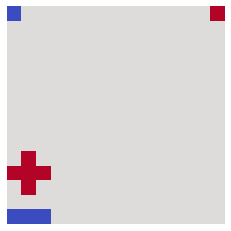

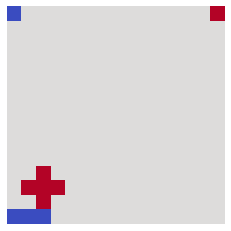

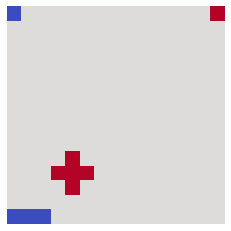

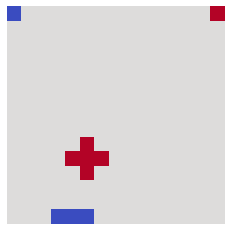

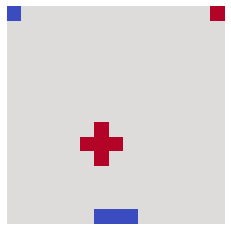

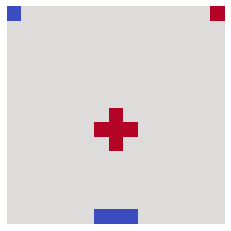

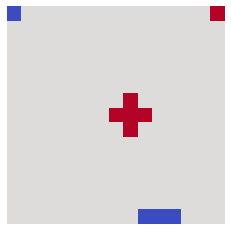

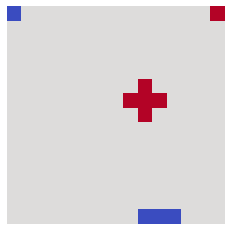

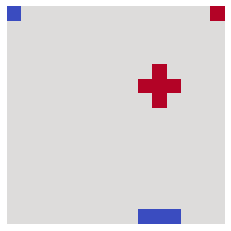

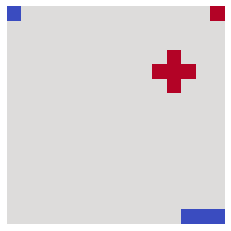

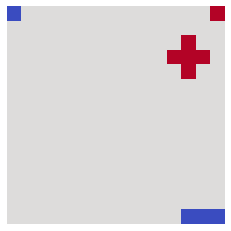

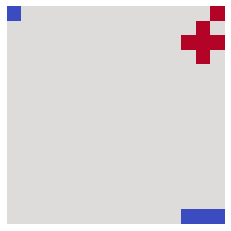

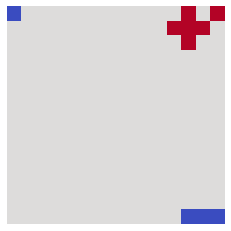

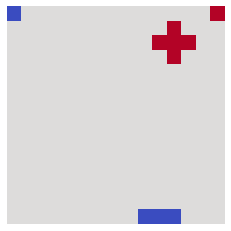

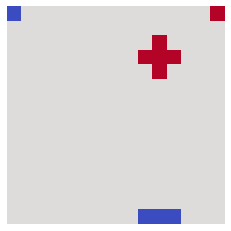

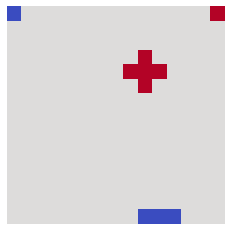

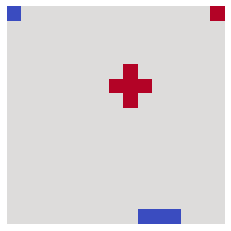

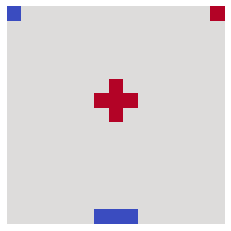

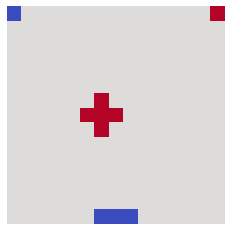

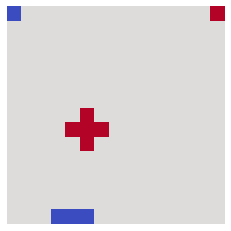

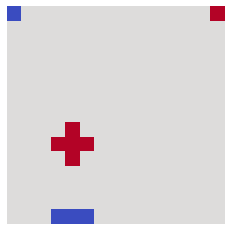

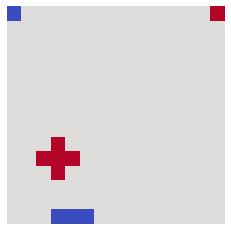

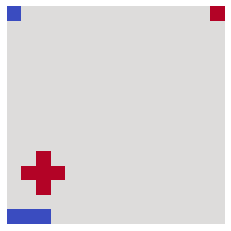

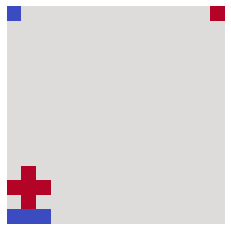

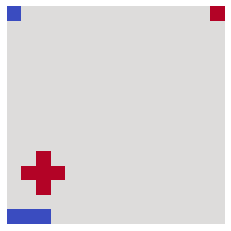

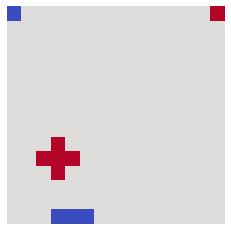

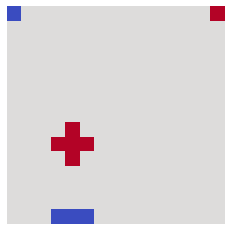

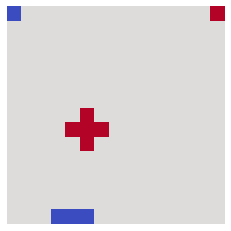

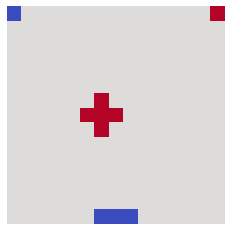

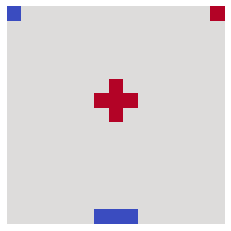

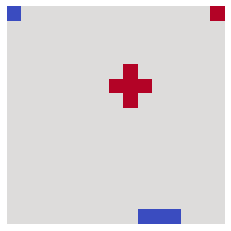

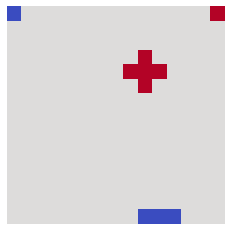

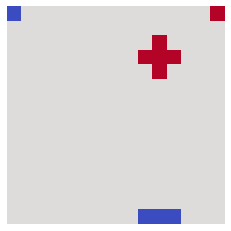

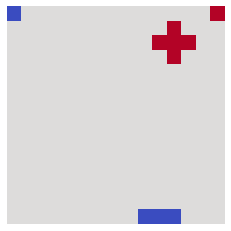

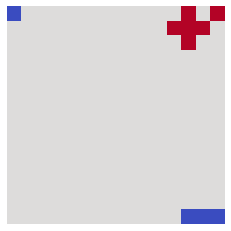

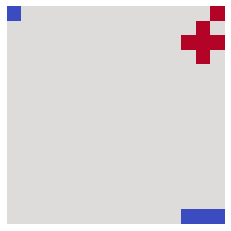

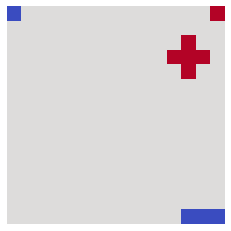

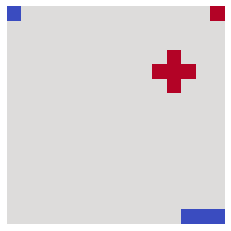

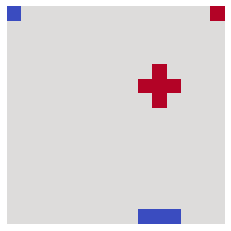

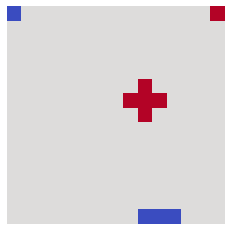

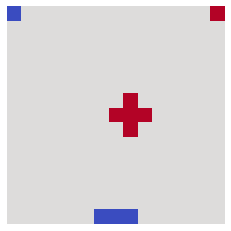

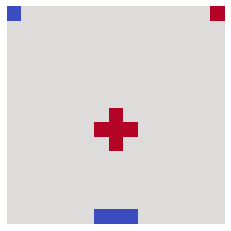

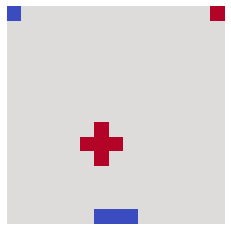

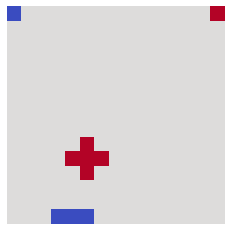

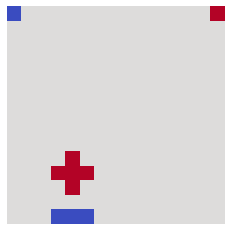

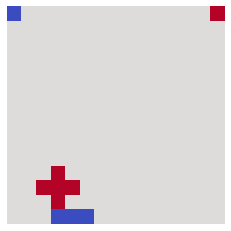

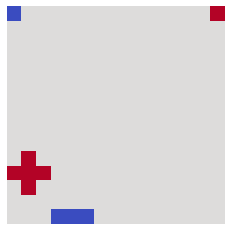

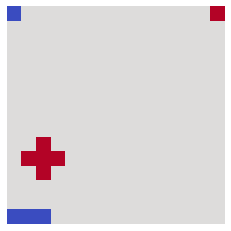

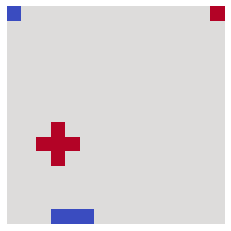

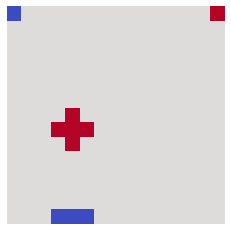

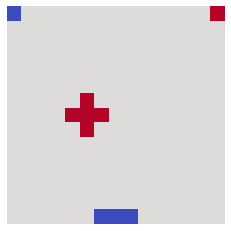

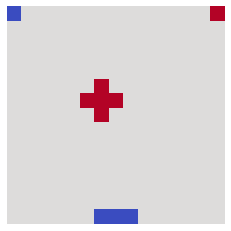

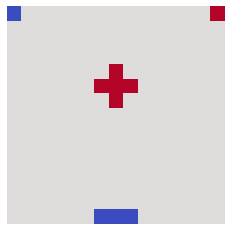

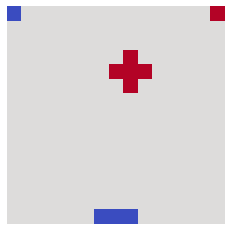

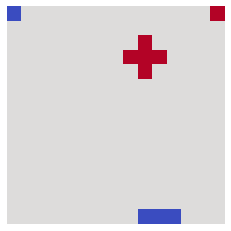

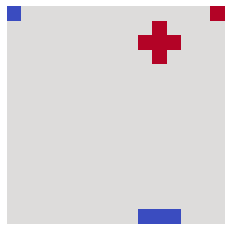

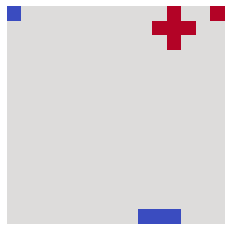

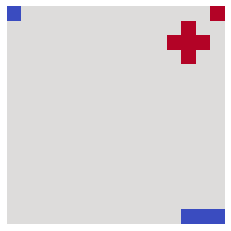

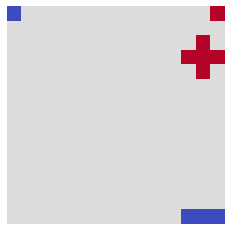

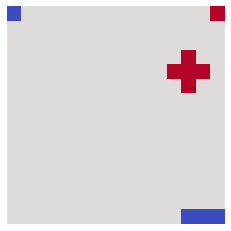

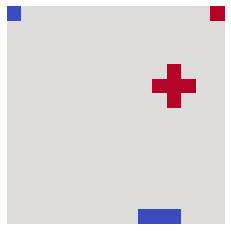

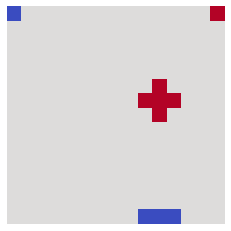

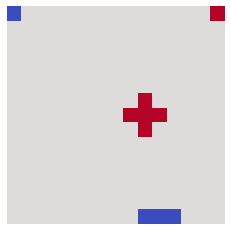

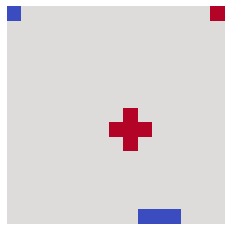

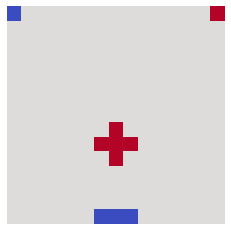

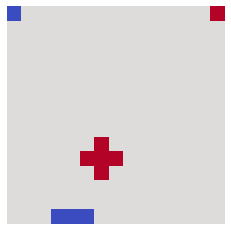

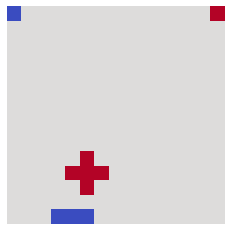

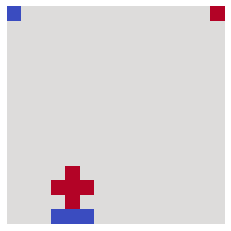

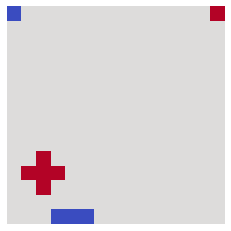

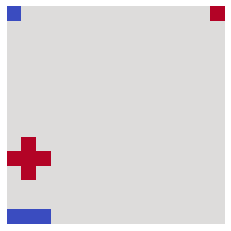

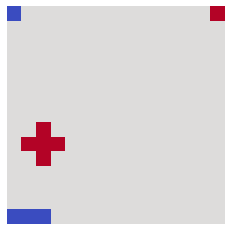

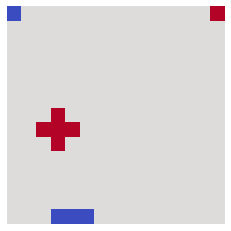

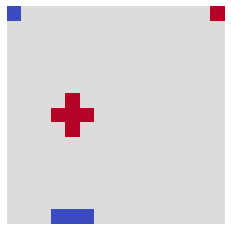

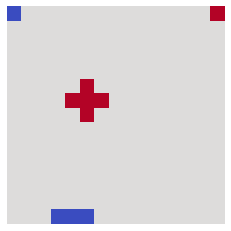

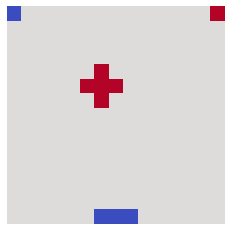

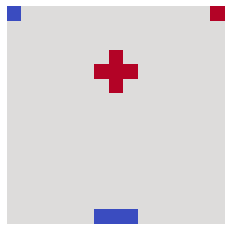

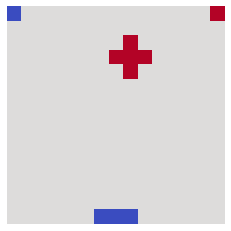

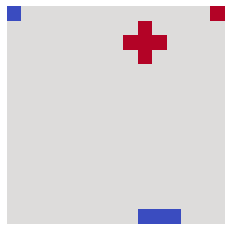

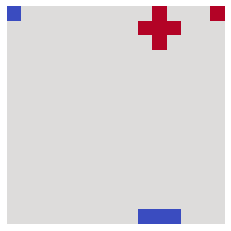

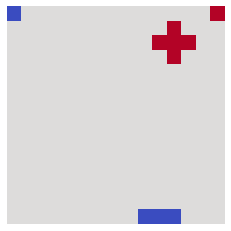

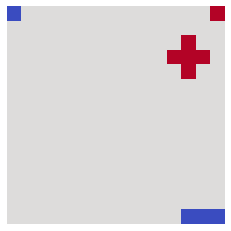

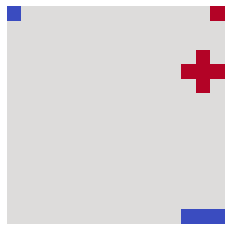

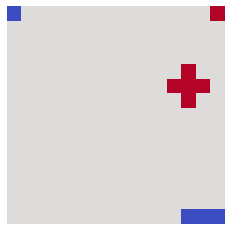

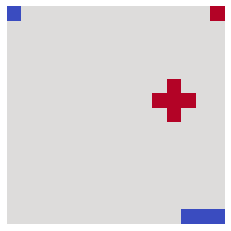

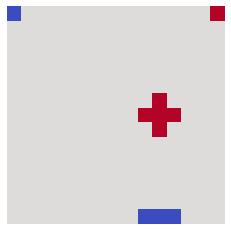

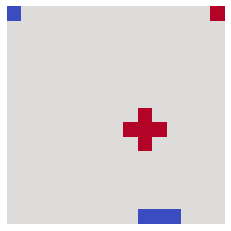

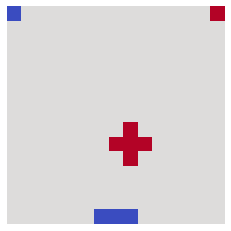

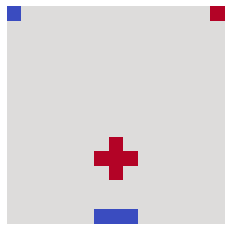

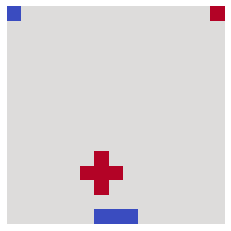

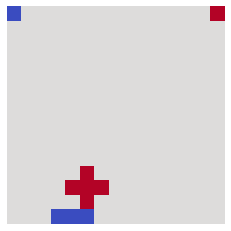

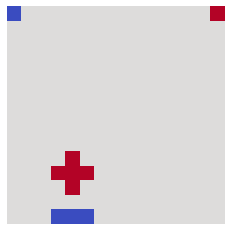

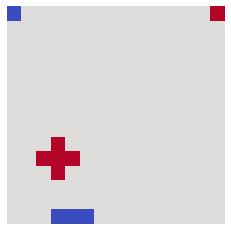

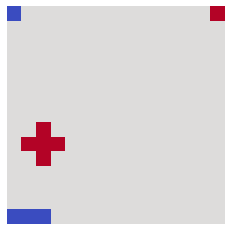

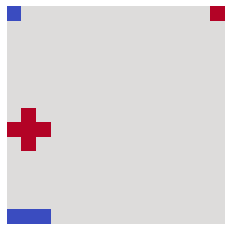

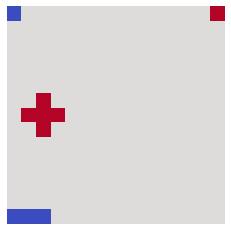

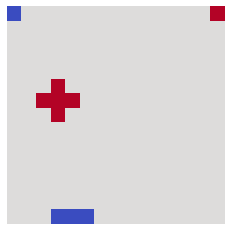

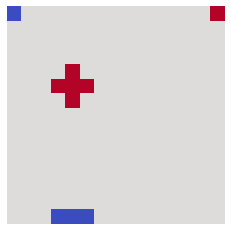

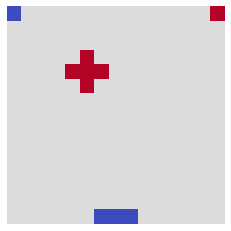

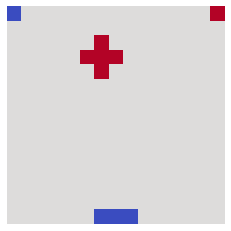

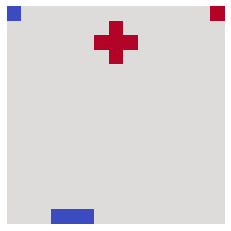

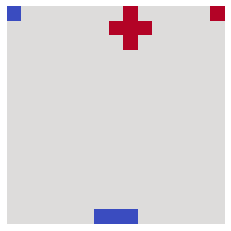

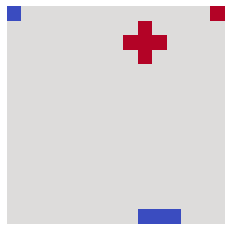

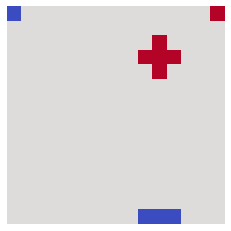

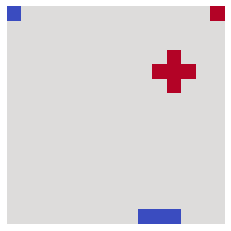

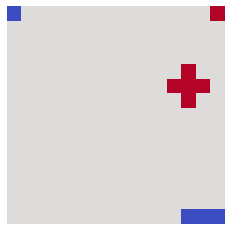

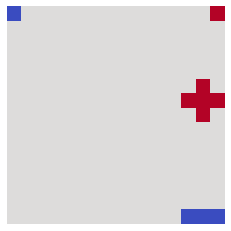

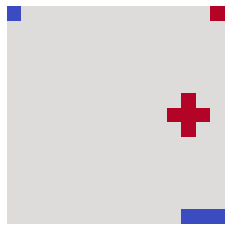

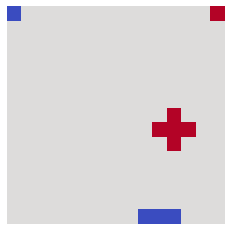

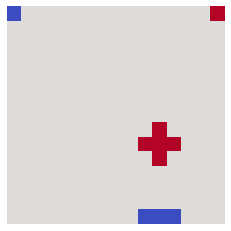

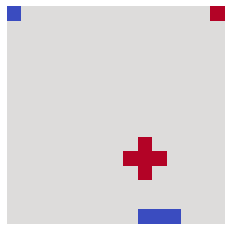

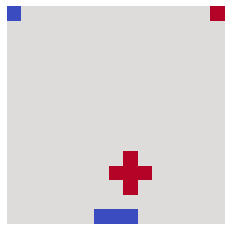

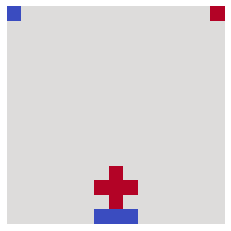

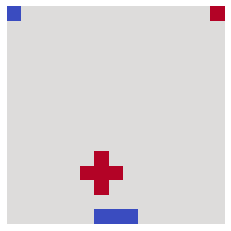

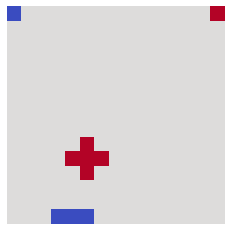

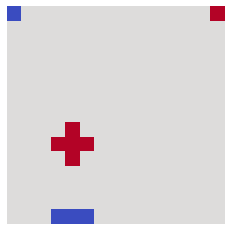

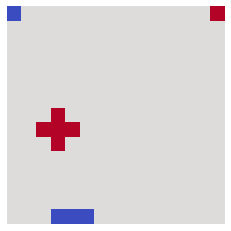

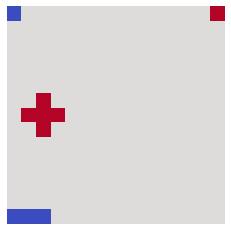

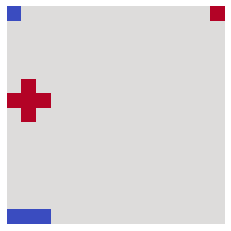

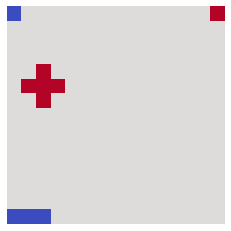

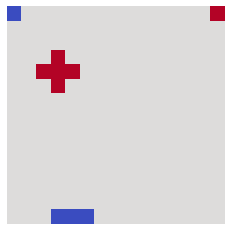

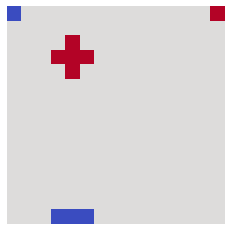

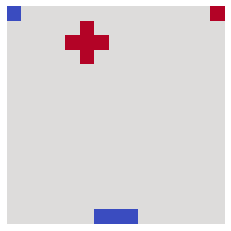

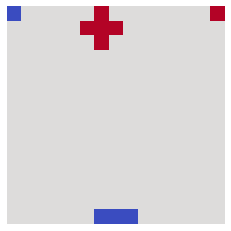

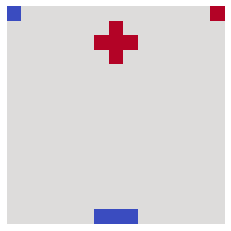

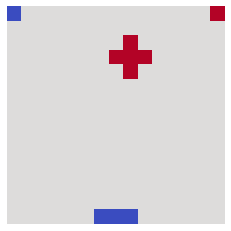

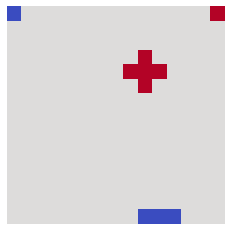

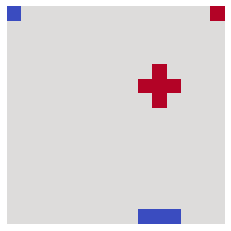

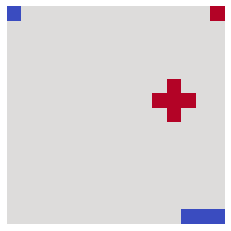

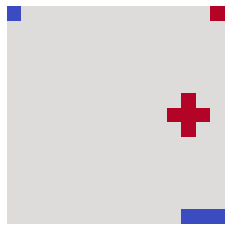

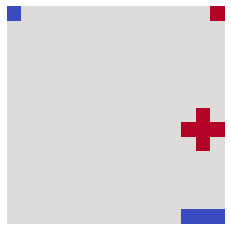

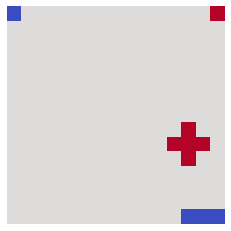

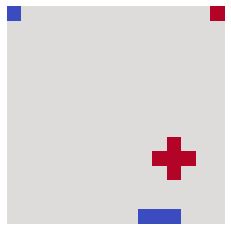

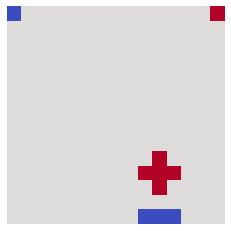

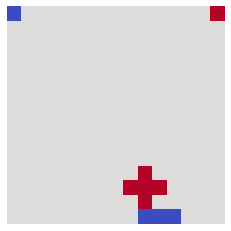

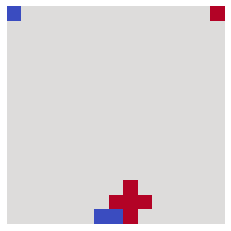

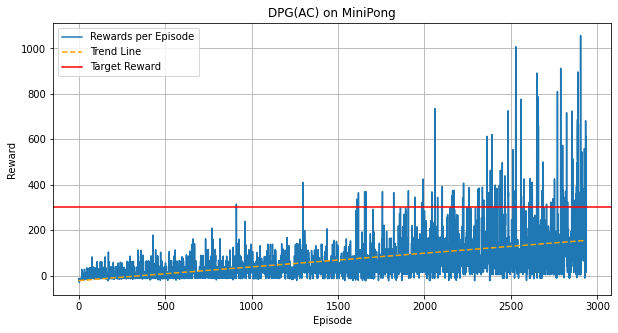

In [49]:
env = ModifiedMiniPongEnv(level = 3, size = 5)
policy = ActorCritic(ninputs, noutputs, lr=5e-3, gamma = 0.95)
train_minipong(env, policy, render=False, targetreward = 300,log_interval=500, finalrender=True)

Test Episode 1/50, Total Reward: 79.5
Test Episode 11/50, Total Reward: 345.0
Test Episode 21/50, Total Reward: 216.5
Test Episode 31/50, Total Reward: 89.5
Test Episode 41/50, Total Reward: 164.0

Test-Average: 263.88
Test-Standard-Deviation: 219.38
PGD test time = 4.029644250869751


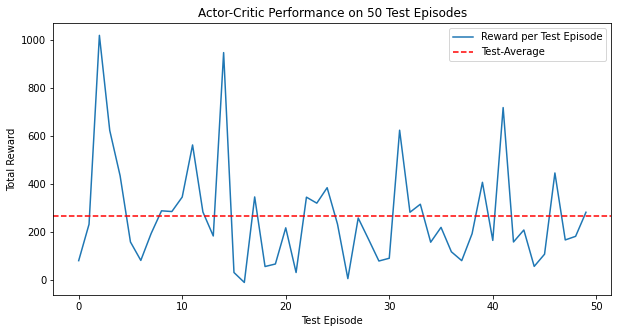

In [50]:
test_rewards, test_avg, test_std = test_actor_critic(env, policy, num_episodes=50)

# Plot the test rewards
plt.figure(figsize=(10, 5))
plt.plot(test_rewards, label='Reward per Test Episode')
plt.axhline(test_avg, color='red', linestyle='--', label='Test-Average')
plt.xlabel('Test Episode')
plt.ylabel('Total Reward')
plt.title('Actor-Critic Performance on 50 Test Episodes')
plt.legend()
plt.show()
